In [162]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.cm as cm
from matplotlib.patches import Patch, ConnectionPatch
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib import gridspec
from scipy.spatial import Voronoi, cKDTree
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import random

In [163]:
sns.set_theme(style="ticks", font_scale=1.6)
CALL_TYPE_COLORS = {'alarm': (0.2823529411764706, 0.47058823529411764, 0.8156862745098039), 
                    'contact': (0.9333333333333333, 0.5215686274509804, 0.2901960784313726), 
                    'departure': (0.41568627450980394, 0.8, 0.39215686274509803), 
                    'distance': (0.8392156862745098, 0.37254901960784315, 0.37254901960784315), 
                    'recruitment': (0.5843137254901961, 0.4235294117647059, 0.7058823529411765), 
                    'triumph': (0.5490196078431373, 0.3803921568627451, 0.23529411764705882)}
DOT_SIZE = 10
ALPHA = .6

In [164]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [165]:
def scatter_projections(
    syllables=None,
    projection=None,
    labels=None,
    ax=None,
    figsize=(10, 10),
    alpha=0.1,
    s=1,
    color="k",
    color_palette="tab20",
    categorical_labels=True,
    show_legend=True,
    tick_pos="bottom",
    tick_size=16,
    cbar_orientation="vertical",
    log_x=False,
    log_y=False,
    grey_unlabelled=True,
    fig=None,
    colornorm=False,
    rasterized=True,
    equalize_axes=True,
    print_lab_dict=False,  # prints color scheme
    lab_dict=CALL_TYPE_COLORS,
):
    """ 
    creates a scatterplot of syllables using some projection
    From Sainburg et al. 2020: https://github.com/timsainb/avgn_paper/blob/V2/avgn/visualization/projections.py
    """
    if projection is None and syllables is None:
            raise ValueError("Either syllables or projections must be passed")

    # color labels
    if labels is not None:
        if categorical_labels:
            if lab_dict is None:
                if (color_palette == "tab10") & (len(np.unique(labels)) < 10):
                    pal = sns.color_palette(color_palette, n_colors=10)
                    pal = np.array(pal)[
                        np.linspace(0, 9, len(np.unique(labels))).astype("int")
                    ]
                else:
                    pal = sns.color_palette(color_palette, n_colors=len(np.unique(labels)))
                lab_dict = {lab: pal[i] for i, lab in enumerate(np.unique(labels))}

            if grey_unlabelled and -1 in lab_dict:
                lab_dict[-1] = [0.95, 0.95, 0.95, 1.0]

            if print_lab_dict:
                print(lab_dict)

            colors = np.array([lab_dict[i] for i in labels])
        else:
            colors = labels  # continuous case
    else:
        colors = color

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if colornorm:
        norm = LogNorm()
    else:
        norm = None

    if categorical_labels or labels is None:
        ax.scatter(
            projection[:, 0],
            projection[:, 1],
            rasterized=rasterized,
            alpha=alpha,
            s=s,
            color=colors,
            norm=norm,
        )

    else:
        cmin = np.quantile(labels, 0.01)
        cmax = np.quantile(labels, 0.99)
        sct = ax.scatter(
            projection[:, 0],
            projection[:, 1],
            vmin=cmin,
            vmax=cmax,
            cmap=plt.get_cmap(color_palette),
            rasterized=rasterized,
            alpha=alpha,
            s=s,
            c=labels,
        )

    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")

    for spine in ax.spines.values():
        spine.set_edgecolor('grey')
        spine.set_linewidth(1.5)

    if labels is not None:
        if categorical_labels == True:
            legend_elements = [
                Line2D([0], [0], marker="o", color=value, label=key)
                for key, value in lab_dict.items()
            ]
        if show_legend:
            if not categorical_labels:
                if cbar_orientation == "horizontal":
                    axins1 = inset_axes(
                        ax,
                        width="50%",  # width = 50% of parent_bbox width
                        height="5%",  # height : 5%
                        loc="upper left",
                    )
                    # cbar = fig.colorbar(sct, cax=axins1, orientation=cbar_orientation

                else:
                    axins1 = inset_axes(
                        ax,
                        width="5%",  # width = 50% of parent_bbox width
                        height="50%",  # height : 5%
                        loc="lower right",
                    )
                cbar = fig.colorbar(sct, cax=axins1, orientation=cbar_orientation)
                cbar.ax.tick_params(labelsize=tick_size)
                axins1.xaxis.set_ticks_position(tick_pos)
            else:
                ax.legend(handles=legend_elements)
    if equalize_axes:
        ax.axis("equal")
    return ax

def scatter_spec(
    z,
    specs,
    column_size=10,
    pal_color="hls",
    matshow_kwargs={"cmap": plt.cm.Greys},
    scatter_kwargs={"alpha": 0.5, "s": 1},
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 1},
    color_points=False,
    figsize=(10, 10),
    range_pad=0.1,
    x_range=None,
    y_range=None,
    enlarge_points=0,
    draw_lines=True,
    n_subset=-1,
    ax=None,
    show_scatter=True,
    border_line_width=1,
    img_origin="lower",
):
    n_columns = column_size * 4 - 4
    pal = sns.color_palette(pal_color, n_colors=n_columns)

    if ax is None:
        fig = plt.figure(figsize=figsize)
        gs = gridspec.GridSpec(column_size, column_size)
        main_ax = fig.add_subplot(gs[1 : column_size - 1, 1 : column_size - 1])

    else:
        fig = ax.figure

       # get subplot bbox in figure coordinates
        bbox = ax.get_position()
        width = bbox.width
        height = bbox.height
        side = min(width, height)

        # center a square in subplot
        cx = bbox.x0 + width/2
        cy = bbox.y0 + height/2
        square_bbox = [cx - side/2, cy - side/2, side, side]

        # main_ax remains the user-passed ax
        main_ax.set_position(square_bbox)

        # now build the ring of small axes manually in figure coordinates
        n_thumbs = len(specs)  # or column_size*4-4
        for i, spec in enumerate(specs):
            # compute row/col in ring as before
            row, col = ... 
            x0 = square_bbox[0] + (col / column_size) * side
            y0 = square_bbox[1] + (row / column_size) * side
            ax_small = fig.add_axes([x0, y0, side/column_size, side/column_size])
            ax_small.matshow(spec, origin="lower", cmap="binary")
            ax_small.set_xticks([])
            ax_small.set_yticks([])
            for spine in ax_small.spines.values():
                spine.set_edgecolor('grey')
                spine.set_linewidth(1.5)

    fig.patch.set_alpha(0)

    # Determine plotting range
    if x_range is None and y_range is None:
        z_arr = np.vstack(z)
        x_sorted = np.sort(z_arr[:, 0])
        y_sorted = np.sort(z_arr[:, 1])
        xmin, xmax = x_sorted[[int(len(z_arr) * 0.01), int(len(z_arr) * 0.99)]]
        ymin, ymax = y_sorted[[int(len(z_arr) * 0.01), int(len(z_arr) * 0.99)]]
        xmin -= (xmax - xmin) * range_pad
        xmax += (xmax - xmin) * range_pad
        ymin -= (ymax - ymin) * range_pad
        ymax += (ymax - ymin) * range_pad
    else:
        xmin, xmax = x_range
        ymin, ymax = y_range

    x_block = (xmax - xmin) / column_size
    y_block = (ymax - ymin) / column_size

    # Filter to points within range
    z = np.array(z)
    mask = (z[:, 0] > xmin) & (z[:, 1] > ymin) & (z[:, 0] < xmax) & (z[:, 1] < ymax)

    if "labels" in scatter_kwargs:
        scatter_kwargs["labels"] = np.array(scatter_kwargs["labels"])[mask]
    specs = np.array(specs)[mask]
    z = z[mask]

    # Respect n_subset only when positive
    if n_subset is not None and n_subset > 0:
        z = z[:n_subset]
        specs = specs[:n_subset]
        if "labels" in scatter_kwargs:
            scatter_kwargs["labels"] = scatter_kwargs["labels"][:n_subset]

    # # Prepare the main axis
    # main_ax = fig.add_subplot(gs[1 : column_size - 1, 1 : column_size - 1])
    if show_scatter and len(z) > 0:
        scatter_projections(projection=z, ax=main_ax, fig=fig, **scatter_kwargs)

    # Build the ring of small axes
    axs = {}
    for column in range(n_columns):
        # decide row/col on the ring
        if column < column_size:
            row = 0
            col = column
        elif (column >= column_size) and (column < (column_size * 2) - 1):
            row = column - column_size + 1
            col = column_size - 1
        elif (column >= ((column_size * 2) - 1)) and (column < (column_size * 3 - 2)):
            row = column_size - 1
            col = column_size - 3 - (column - column_size * 2)
        else:
            row = n_columns - column
            col = 0

        axs[column] = {"ax": fig.add_subplot(gs[row, col]), "col": col, "row": row}

        # geometric center for this small axis (in data coords)
        xpos = xmin + x_block * col + x_block / 2
        ypos = ymax - y_block * row - y_block / 2
        axs[column]["xpos"] = xpos
        axs[column]["ypos"] = ypos

    main_ax.set_xlim([xmin, xmax])
    main_ax.set_ylim([ymin, ymax])
    for spine in main_ax.spines.values():
            spine.set_linewidth(0)
    main_ax.patch.set_alpha(0)

    if len(z) == 0:
        gs.update(wspace=0, hspace=0)
        return fig  # nothing to connect

    # Voronoi over the ring cell centers, then assign each z-point to nearest center
    points = np.array([[axs[i]["xpos"], axs[i]["ypos"]] for i in axs.keys()])
    voronoi_kdtree = cKDTree(points)
    # index of closest cell center for each z point
    _, point_regions = voronoi_kdtree.query(z)

    # Track which z points have been used so we don't reuse the same one
    used = np.zeros(len(z), dtype=bool)
    lines_list = []

    # Loop through cells on the ring and pick a representative z point
    for key in axs.keys():
        ax_small = axs[key]["ax"]

        # pick a z point assigned to this region that hasn't been used
        in_region = np.where((point_regions == key) & (~used))[0]

        if in_region.size:
            chosen_point = np.random.choice(in_region)
        else:
            # fallback: choose nearest unused to the cell center
            center = np.array([axs[key]["xpos"], axs[key]["ypos"]])
            avail = np.where(~used)[0]
            dists = np.linalg.norm(z[avail] - center, axis=1)
            chosen_point = avail[np.argmin(dists)]

        used[chosen_point] = True

        # draw the spectrogram in the small axis
        ax_small.matshow(
            specs[chosen_point],
            origin=img_origin,
            interpolation="none",
            aspect="auto",
            **matshow_kwargs,
        )
        ax_small.set_xticks([])
        ax_small.set_yticks([])
        ax_small.patch.set_alpha(0)

        # colored borders if requested
        if color_points:
            plt.setp(ax_small.spines.values(), color=pal[key])
        for spine in ax_small.spines.values():
            spine.set_linewidth(border_line_width)

        # optionally enlarge and color the chosen main point
        if enlarge_points > 0:
            dot_color = pal[key] if color_points else "k"
            main_ax.scatter(
                [z[chosen_point, 0]],
                [z[chosen_point, 1]],
                color=dot_color,
                s=enlarge_points,
                zorder=3,
            )

        # draw dashed connection using robust transforms
        if draw_lines:
            # pick an anchor on the edge of the small subplot (in Axes coords)
            line_end_pos = [0.5, 0.5]
            if axs[key]["row"] == 0:
                line_end_pos[1] = 0
            if axs[key]["row"] == column_size - 1:
                line_end_pos[1] = 1
            if axs[key]["col"] == 0:
                line_end_pos[0] = 1
            if axs[key]["col"] == column_size - 1:
                line_end_pos[0] = 0

            con = ConnectionPatch(
                xyA=(z[chosen_point, 0], z[chosen_point, 1]),
                coordsA=main_ax.transData,          # data coords on main axis
                xyB=tuple(line_end_pos),
                coordsB=ax_small.transAxes,         # axes coords on small subplot
                axesA=main_ax,
                axesB=ax_small,
                **line_kwargs,
            )
            fig.add_artist(con)
            lines_list.append(con)

    if isinstance(gs, gridspec.GridSpec):
        gs.update(wspace=0, hspace=0)
    else:
        plt.subplots_adjust(wspace=0, hspace=0)
    return fig

# Load results and plot

In [166]:
with open(f"embeddings_for_visualization_20251002_160646.pkl", "rb") as f:
    vis_data = pickle.load(f)

results_df = pd.read_pickle("results_20251002_160646.pkl")

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/53669097.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/53669097.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/53669097.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/53669097.py:54: UserWarning: set_ticklabe

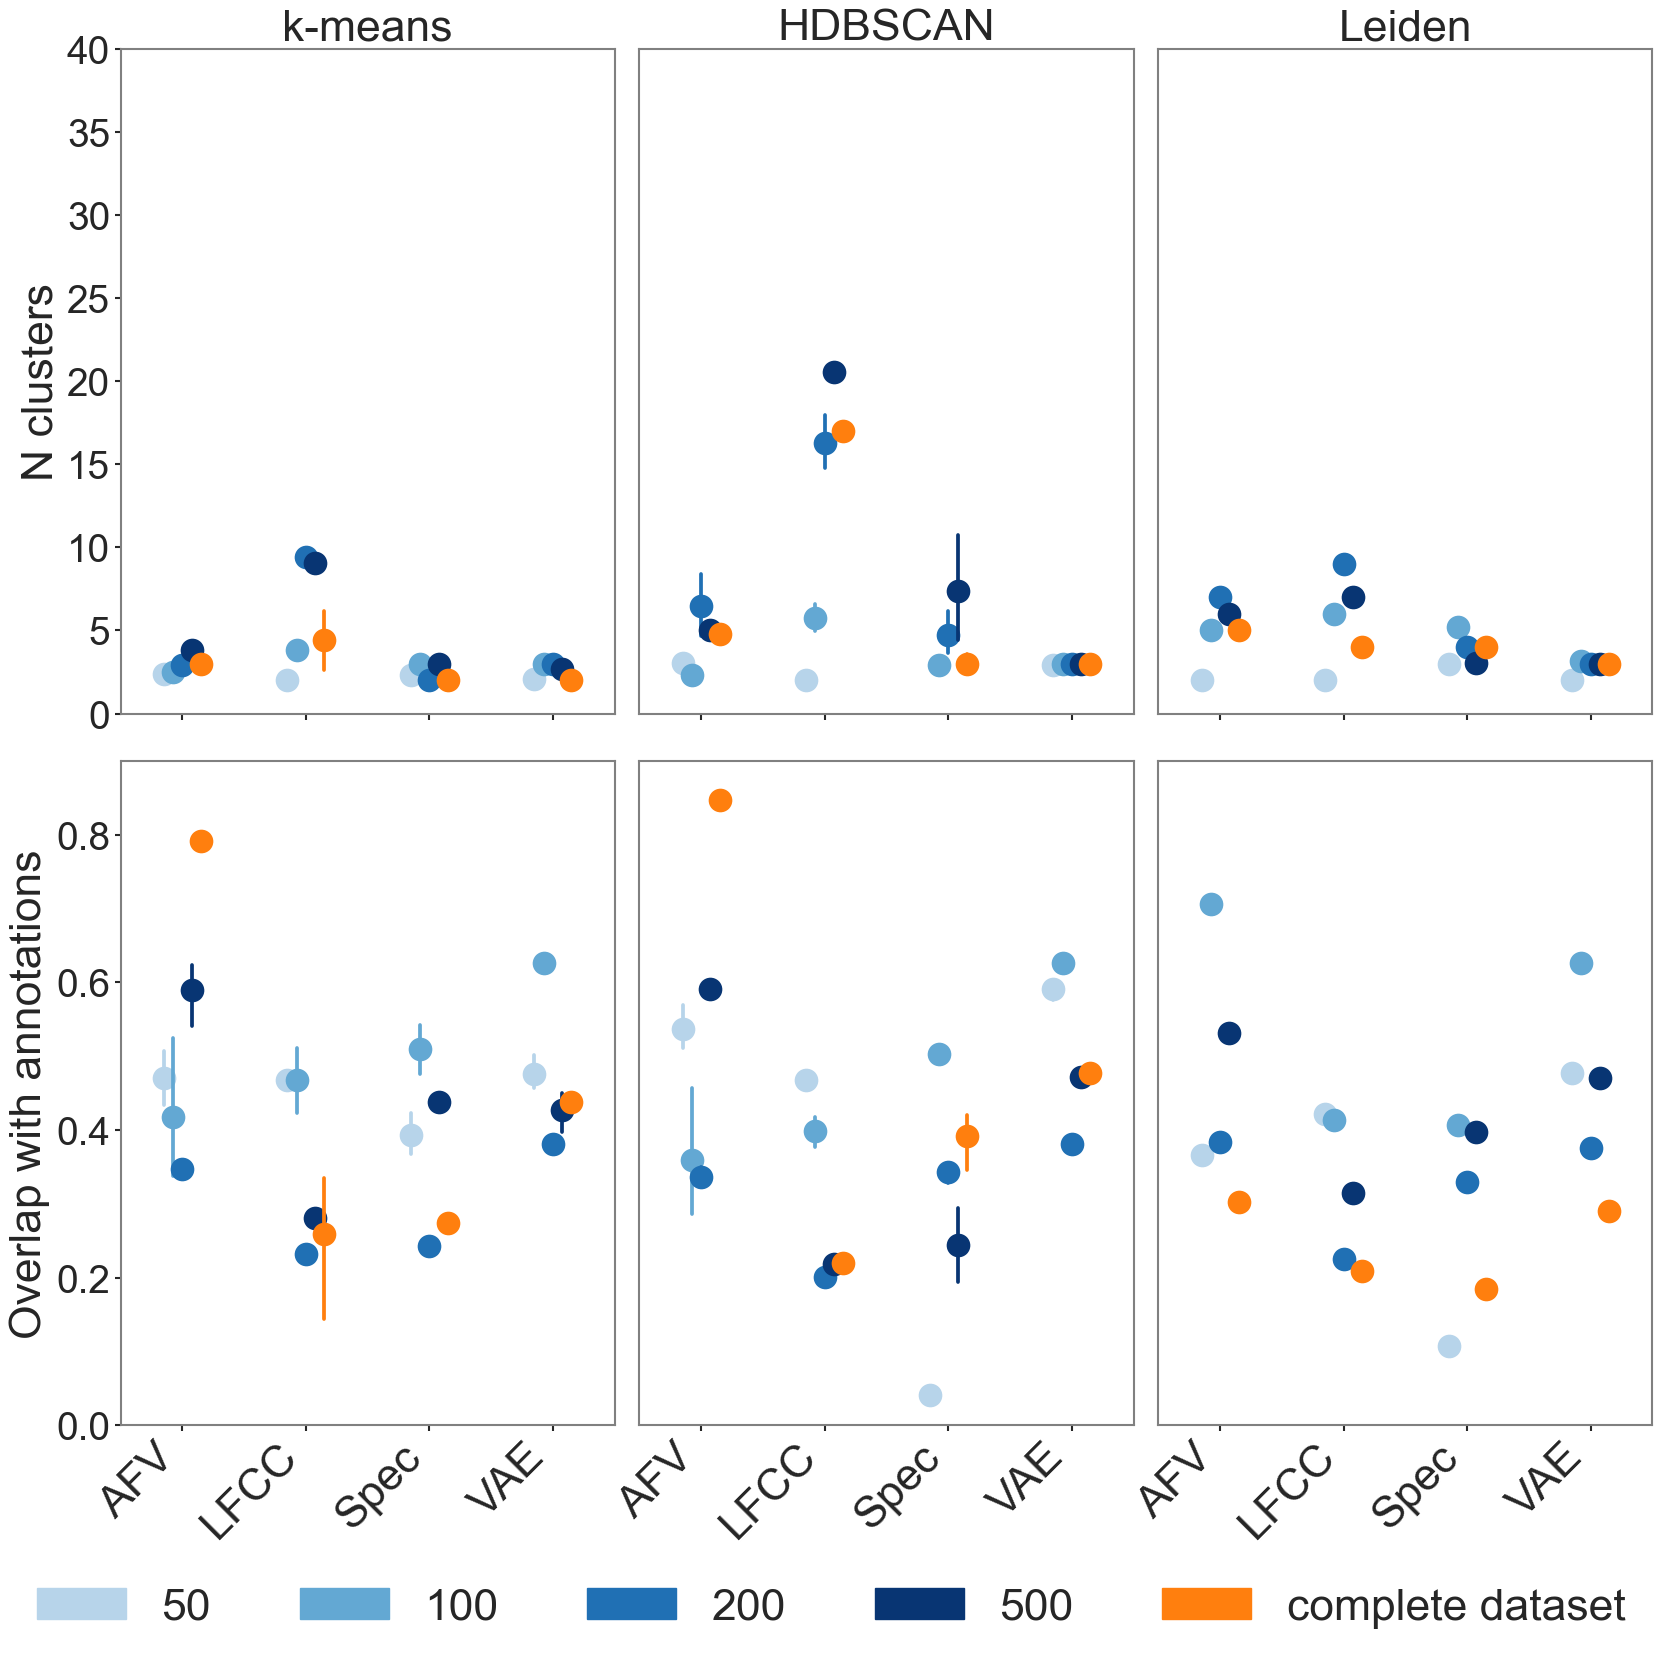

In [167]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 2) & (results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 40)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/2080746171.py:54: UserWarning: set_

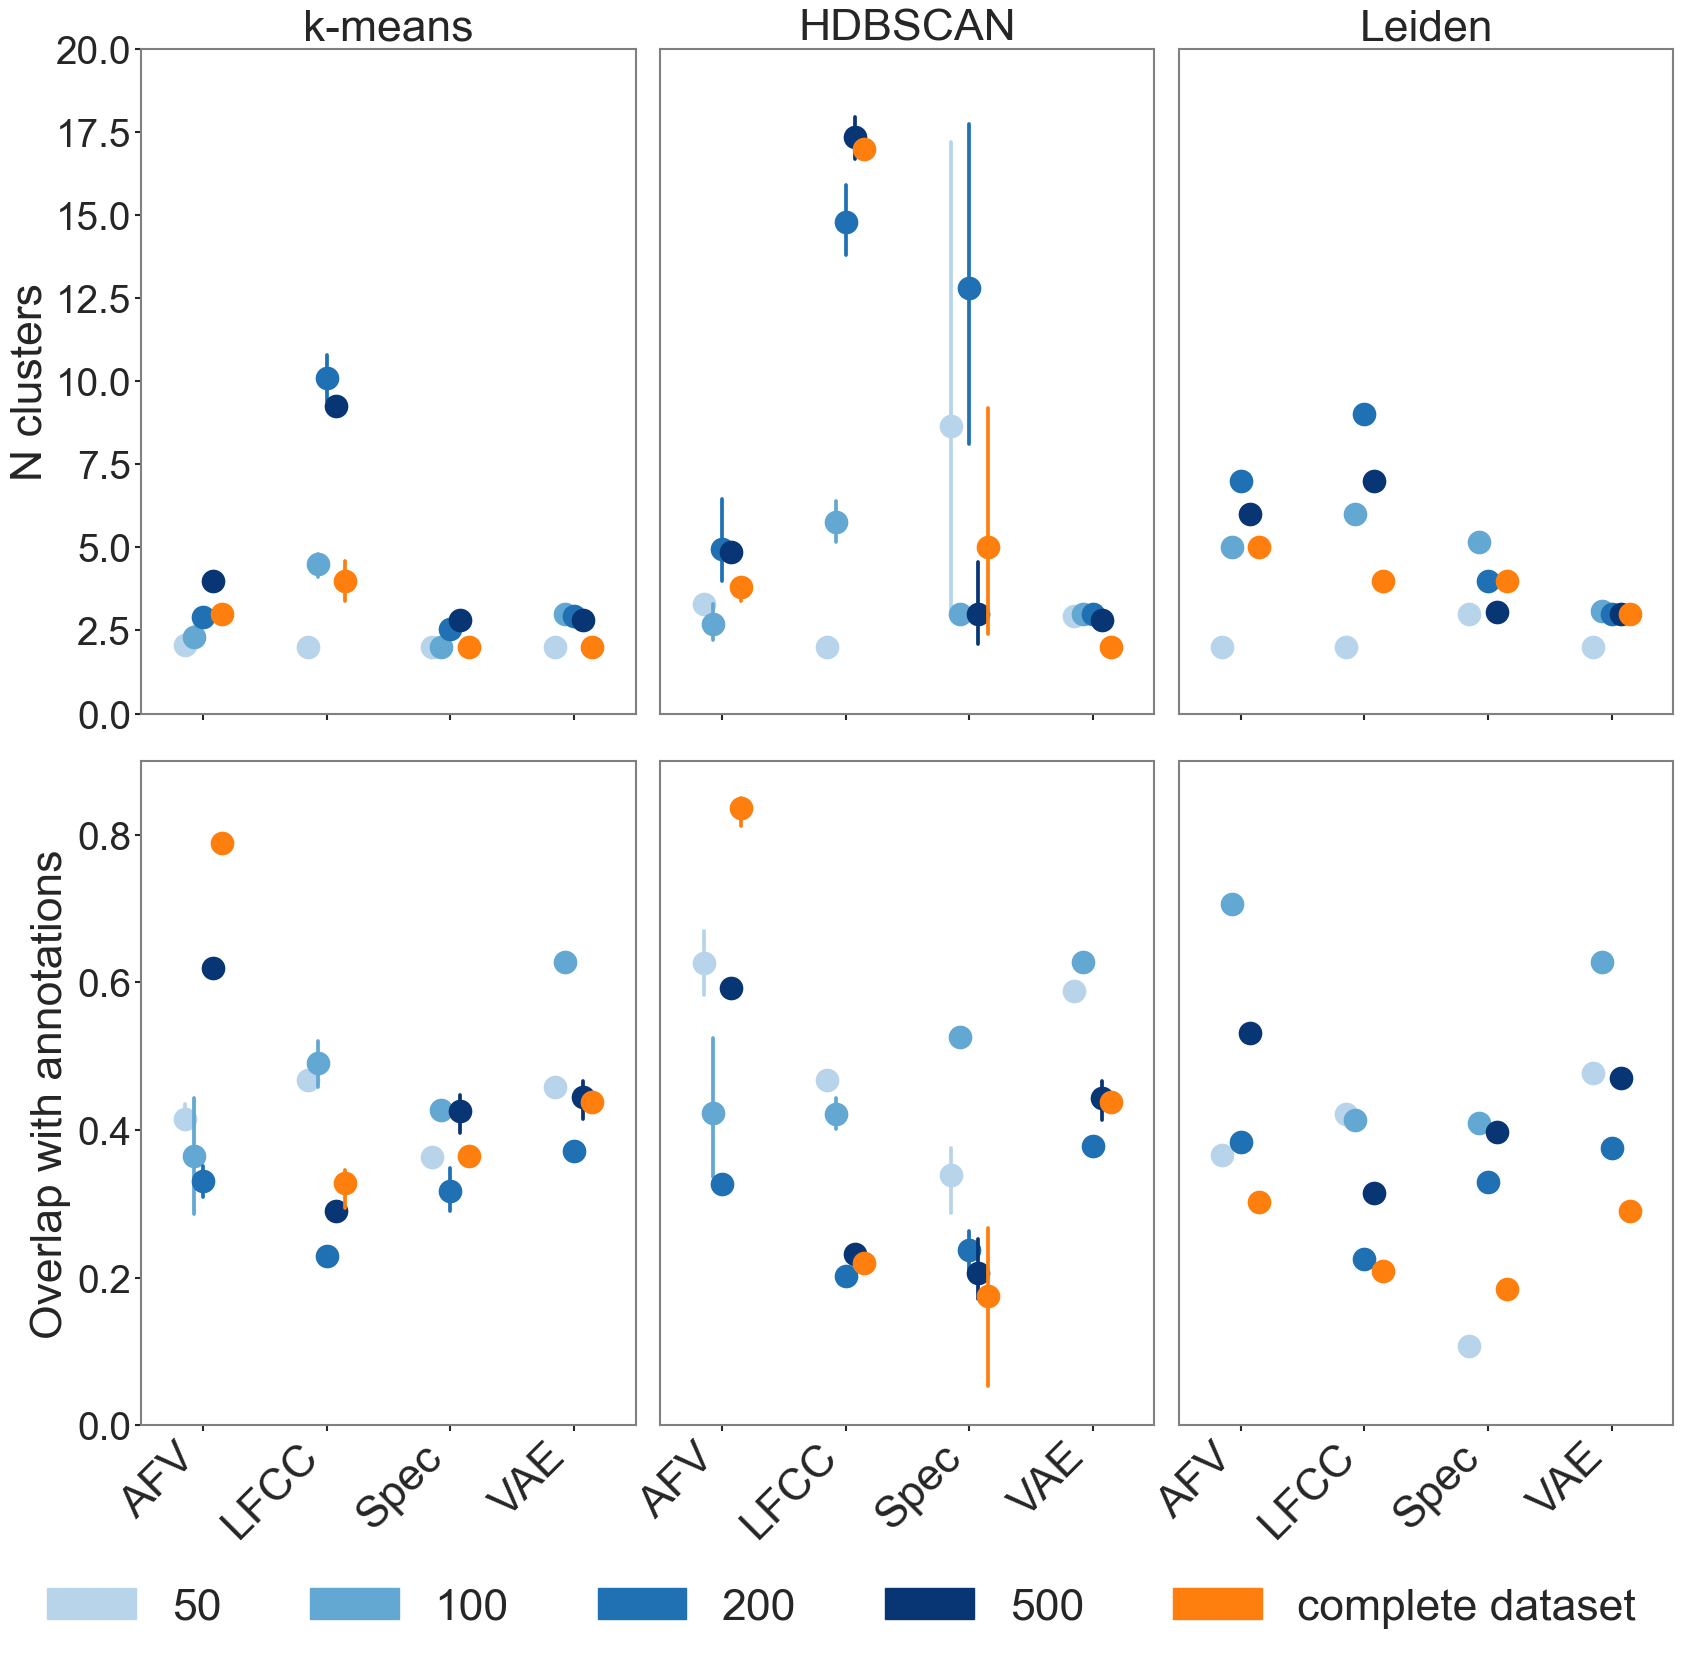

In [168]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 20) & (results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/154244901.py:54: UserWarning: set_tick

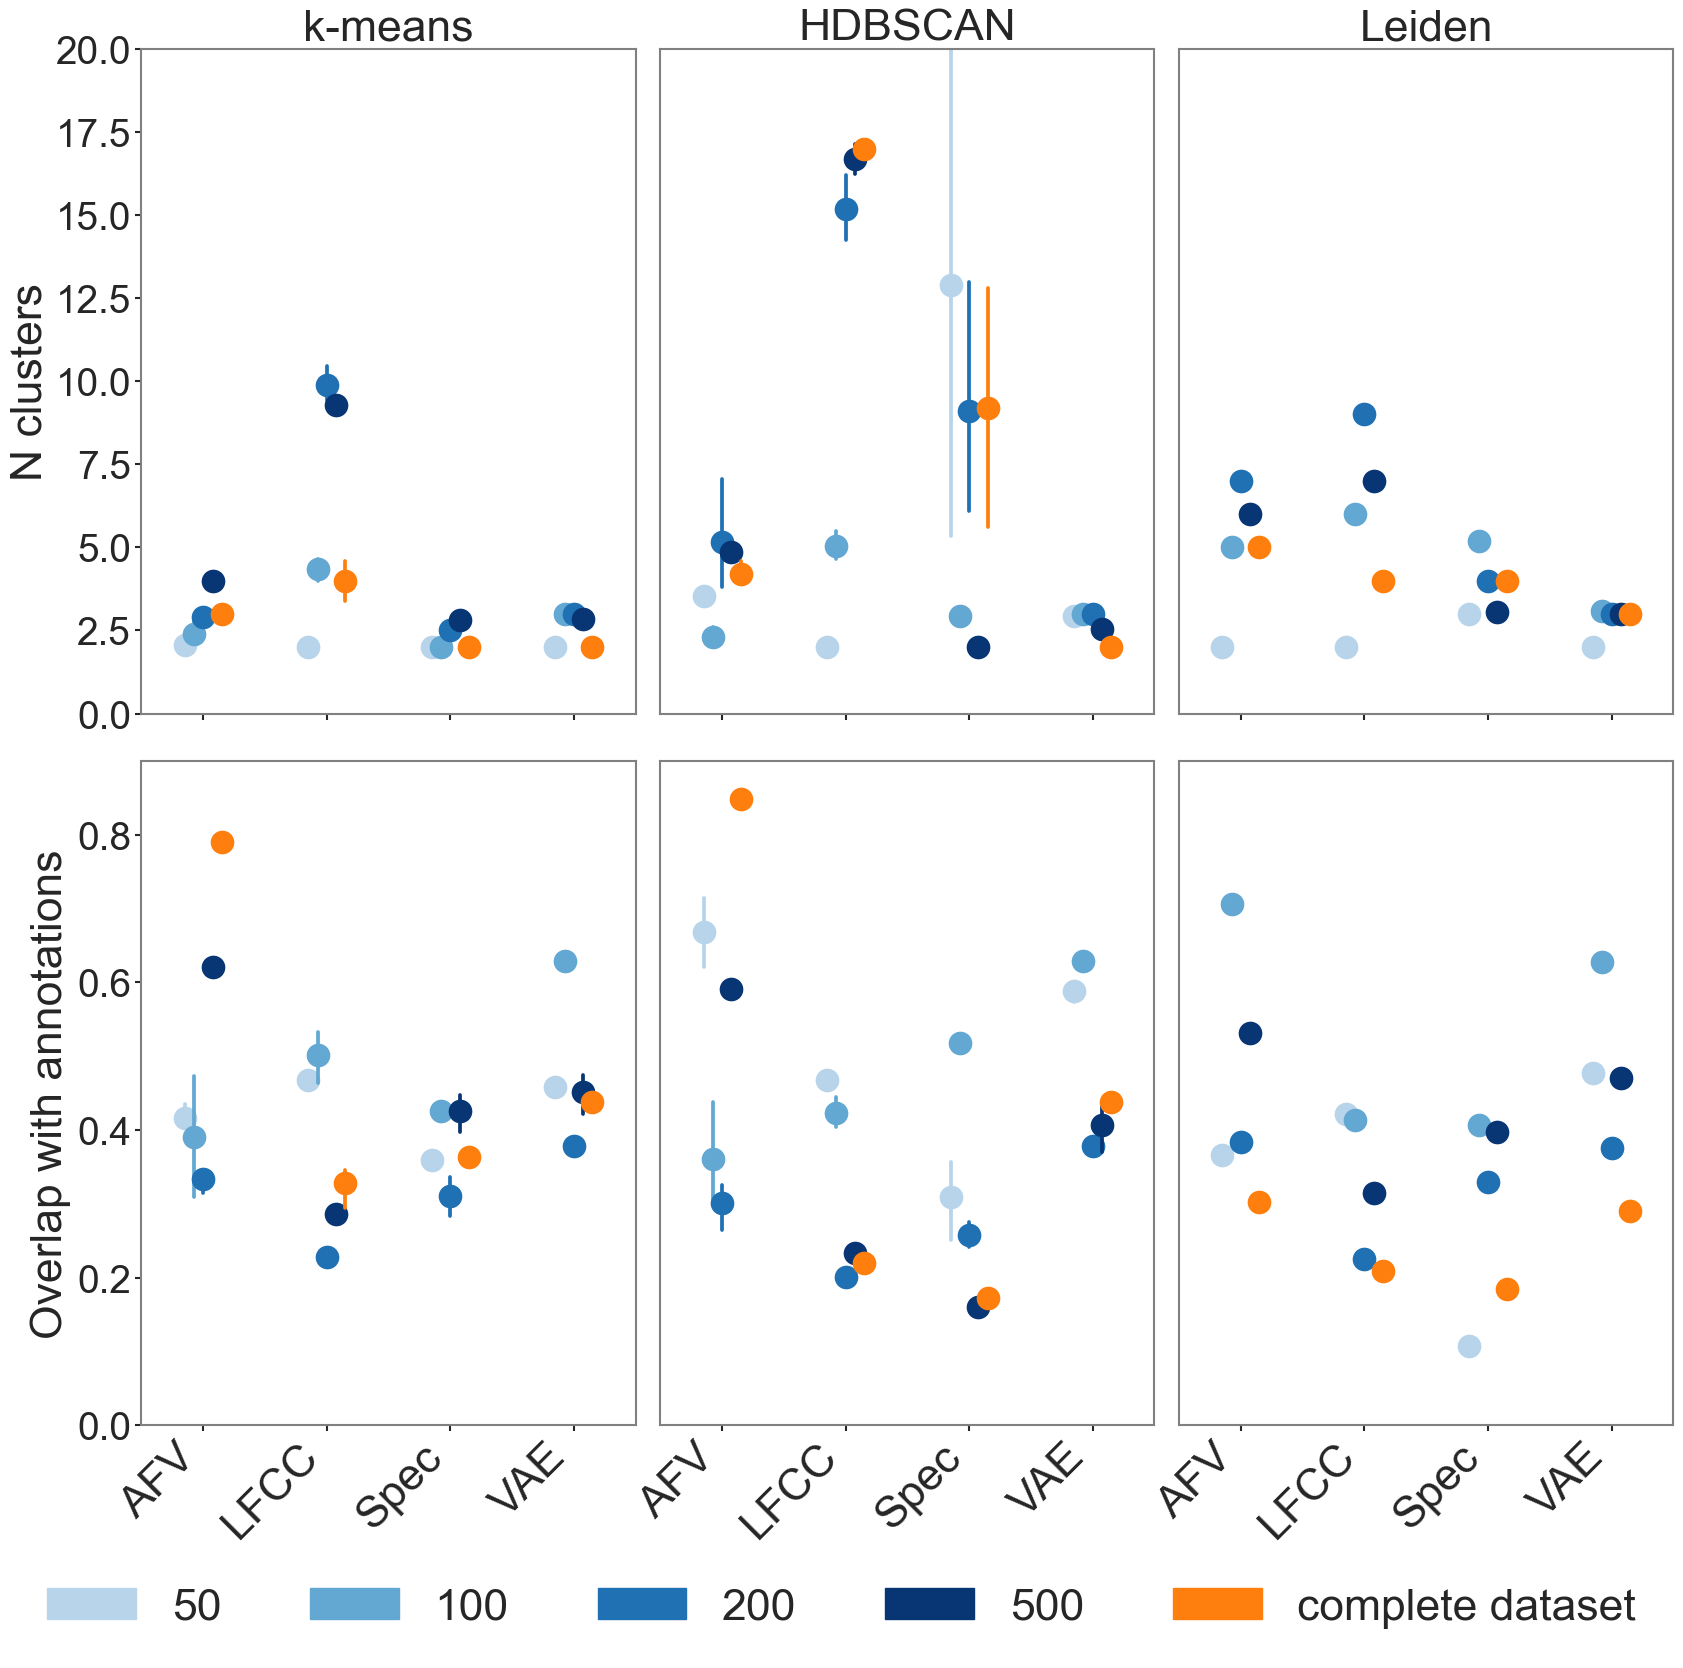

In [169]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 100) & (results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/1841806617.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/1841806617.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/1841806617.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/1841806617.

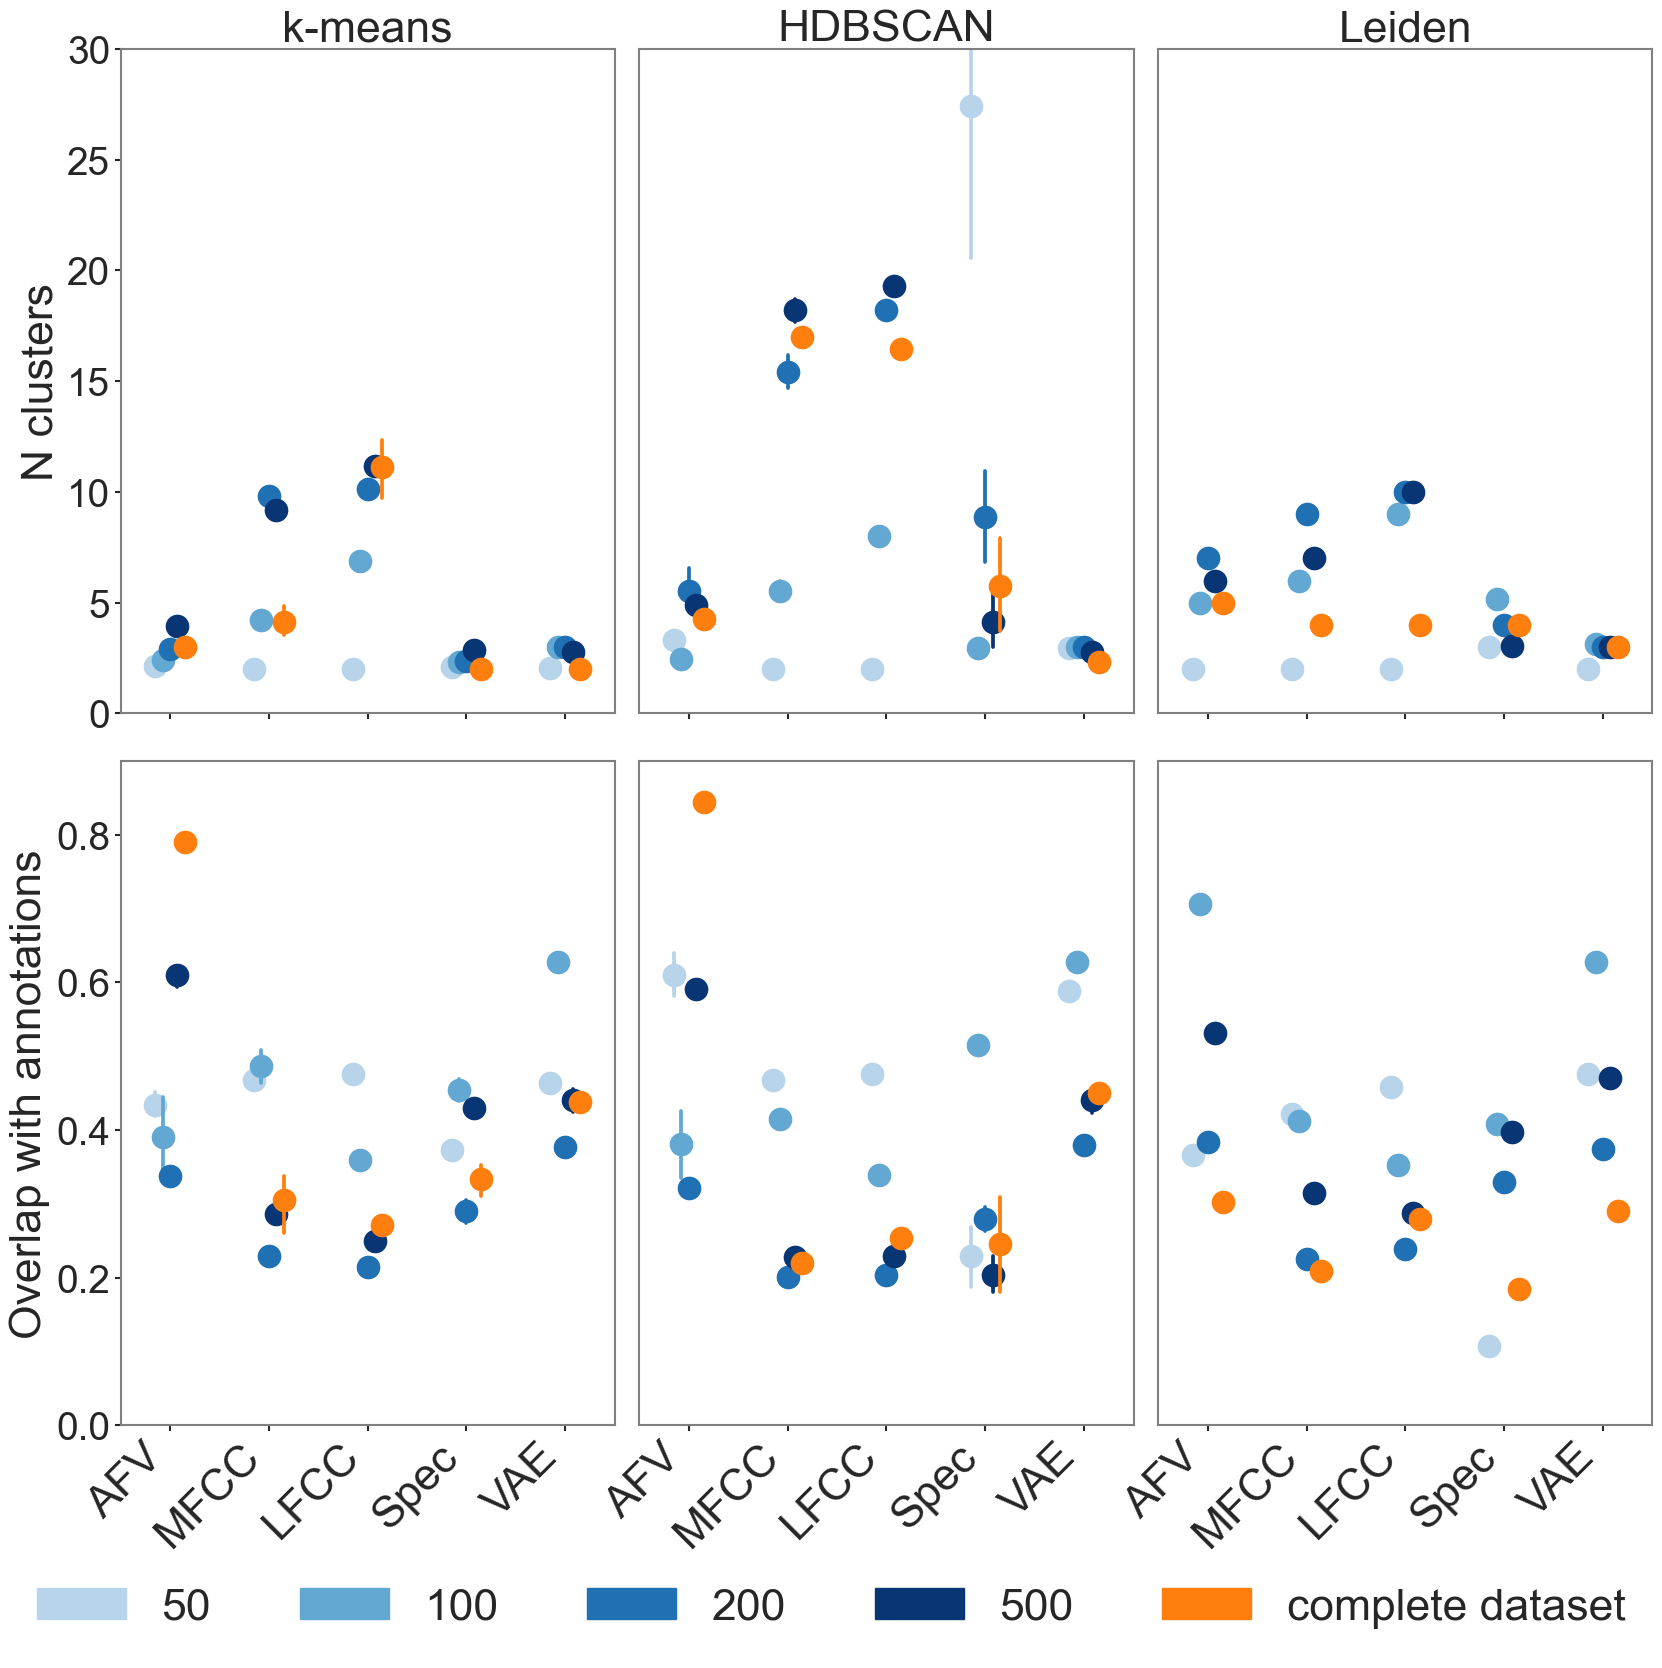

In [170]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "MFCC", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15,
            zorder=2
        )

        # sns.stripplot(
        #     x="Representation", 
        #     y=metric,  
        #     data=data, 
        #     ax=axs[row, col], 
        #     hue=hue_col,
        #     palette=palette,
        #     hue_order=hue_levels_metric,
        #     alpha=.15,
        #     dodge=.1,
        #     jitter=.7,
        #     legend=False,
        #     size=13,
        #     zorder=1
        # )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 30)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/2417974276.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/2417974276.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/2417974276.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_29008/2417974276.py:74: UserWarning: set_

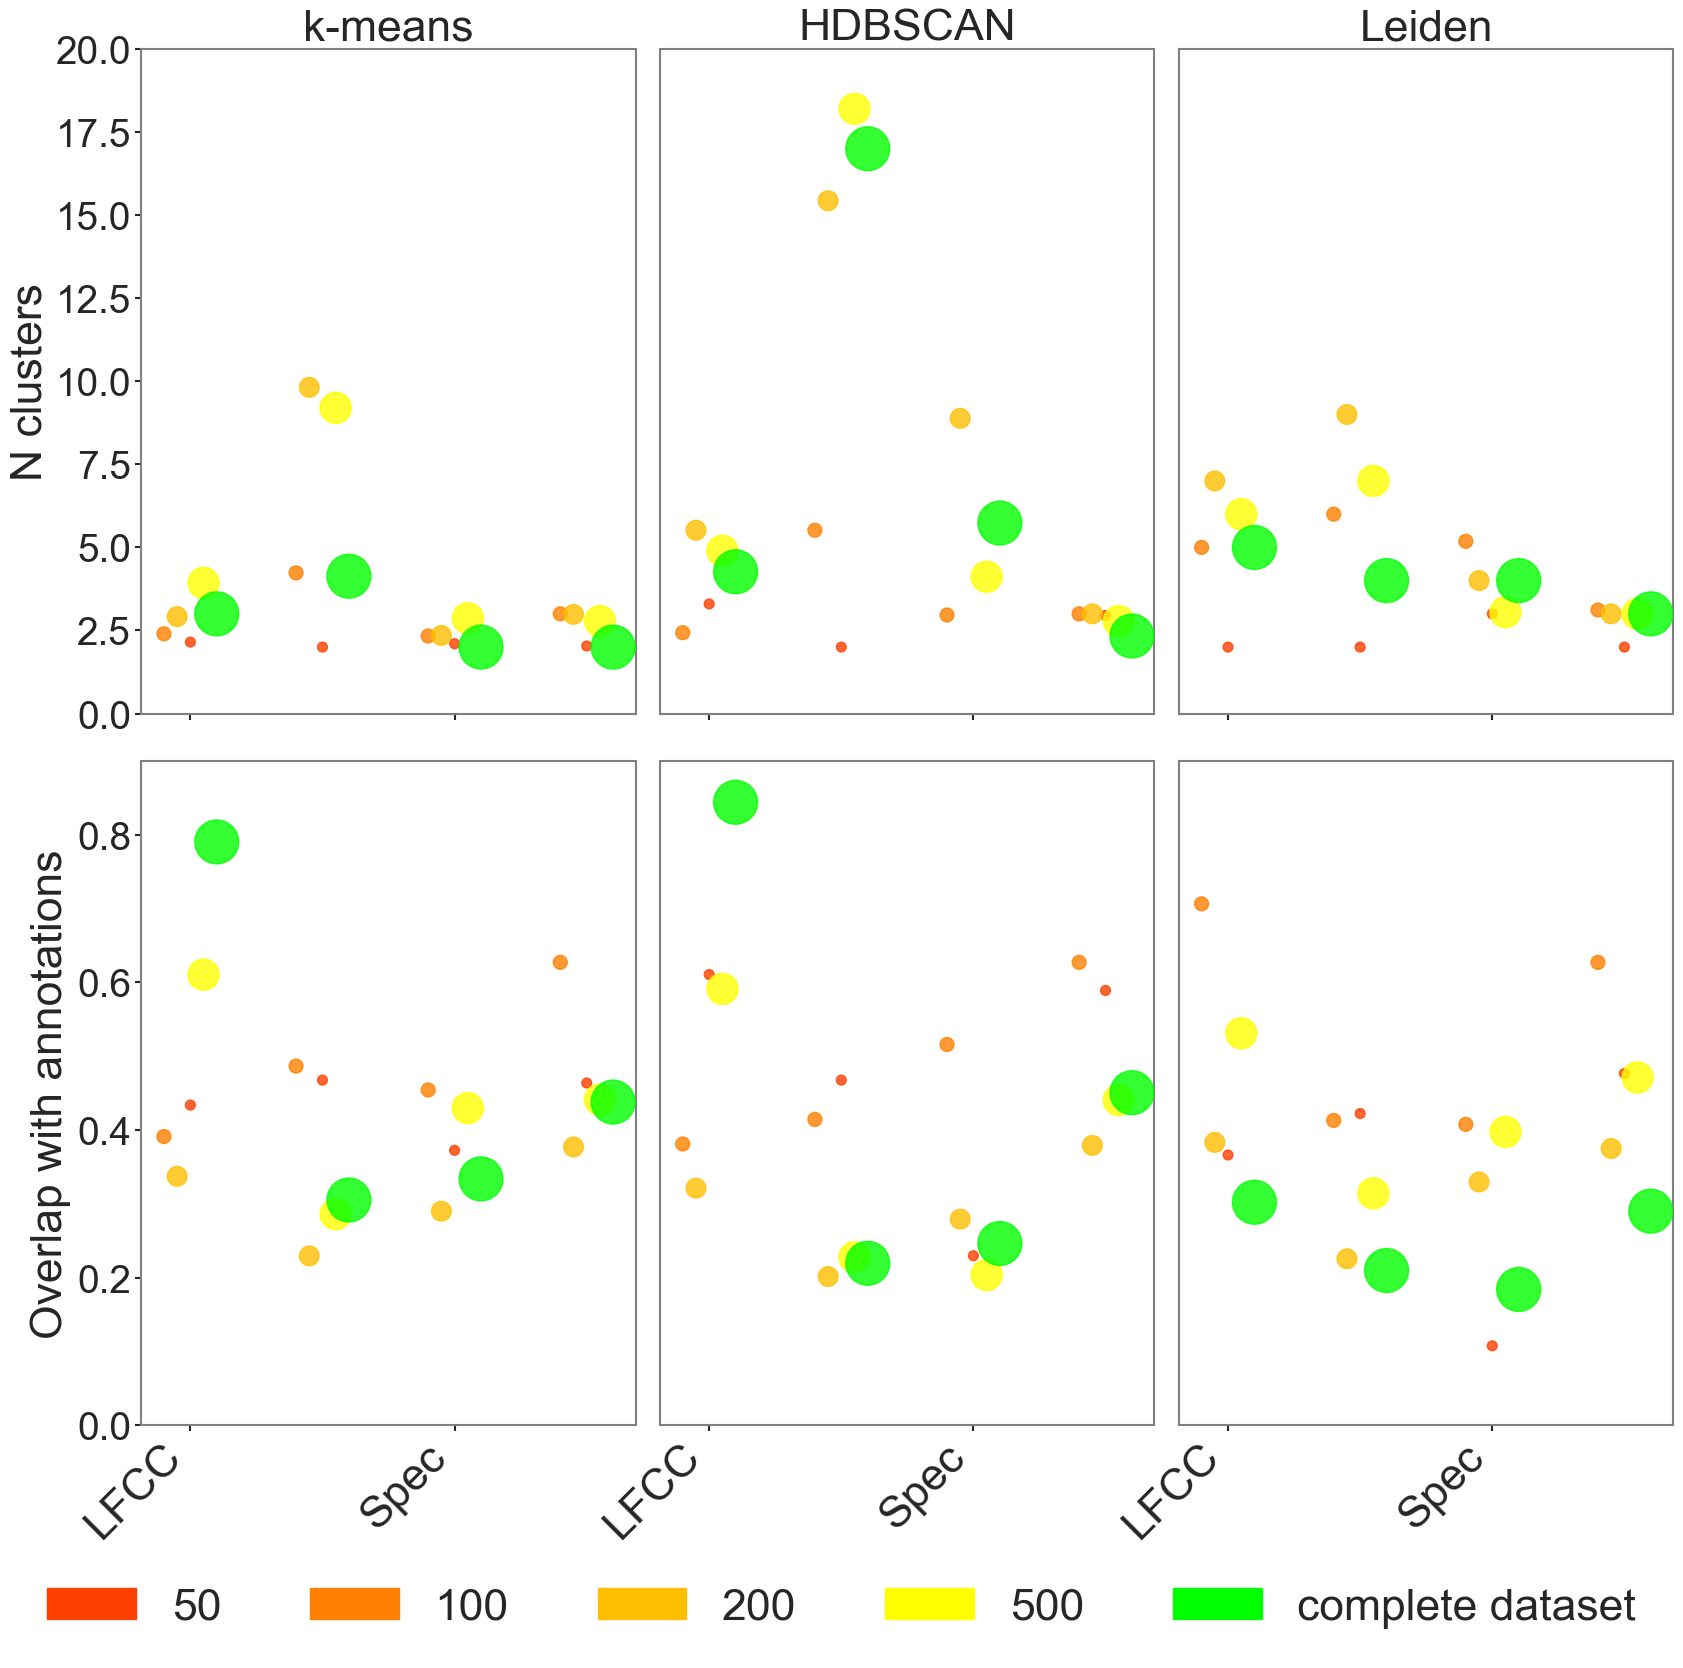

In [171]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  "#ff4000",   # darkest blue
            100: "#ff8000",
            200: "#ffbf00",
            500: "#ffff00",   # lightest blue
            "complete dataset": "#00ff00",  # tab20 orange
        }

        hue_col = "Subset size"
        size_mapping = {
            50:  50,  
            100: 100,
            200: 200,
            500: 500,  
            "complete dataset": 1000
        }

        means = pd.DataFrame(data.groupby(["Representation", "Subset size"])[metric].mean().reset_index())
        x_positions = {
            rep: i for i, rep in enumerate(means["Representation"].unique())
        }
        hue_levels = means["Subset size"].unique()
        n_hues = len(hue_levels)
        dodge_amount = 0.1

        offsets = {
            level: (i - (n_hues - 1) / 2) * dodge_amount
            for i, level in enumerate(sorted(hue_levels, key=lambda x: str(x)))
        }

        # scatter each subset size with an offset x
        for subset in hue_levels:
            sub_means = means[means["Subset size"] == subset]
            x_vals = [x_positions[r] + offsets[subset] for r in sub_means["Representation"]]
            y_vals = sub_means[metric].values

            axs[row, col].scatter(
                x_vals,
                y_vals,
                s=[size_mapping[subset]] * len(x_vals),
                color=palette[subset],
                label=subset,
                alpha=0.8,
                zorder=3,
            )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


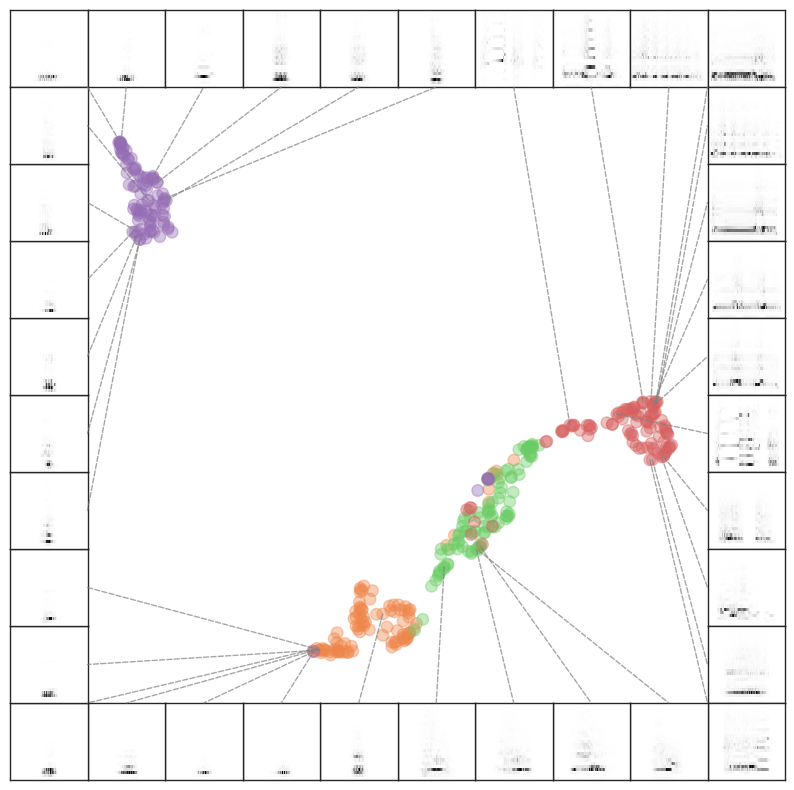

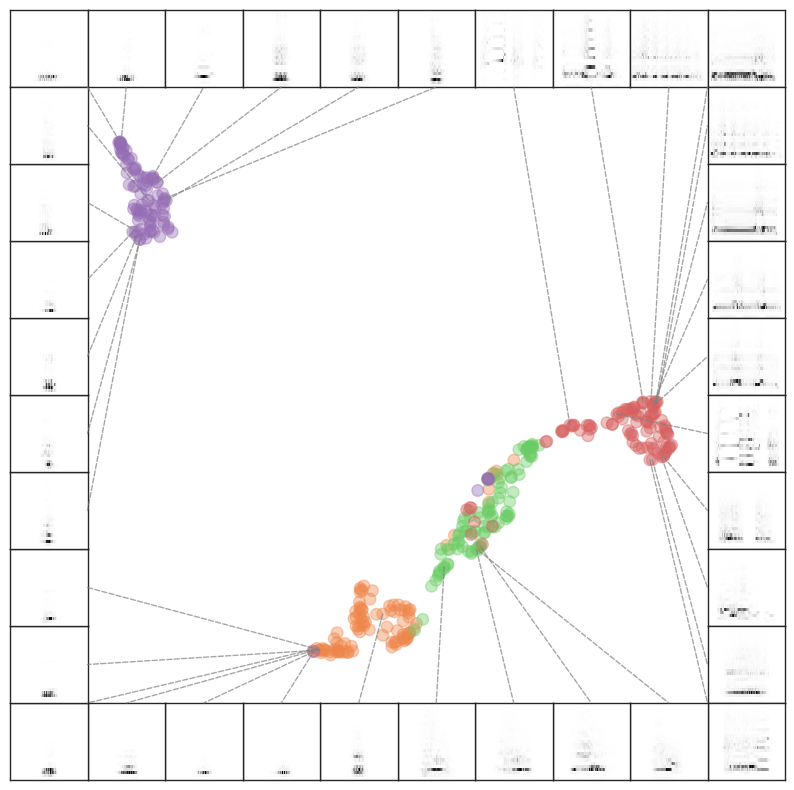

In [172]:
vis_data_sub = vis_data[0]
scatter_spec(
    vis_data_sub["embeddings"]["paf"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"],
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


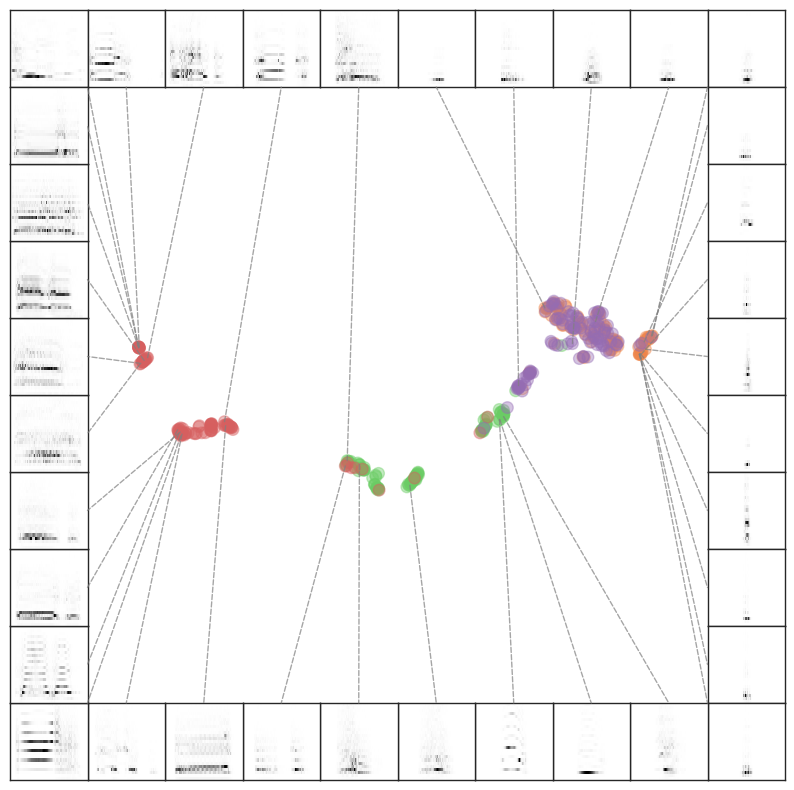

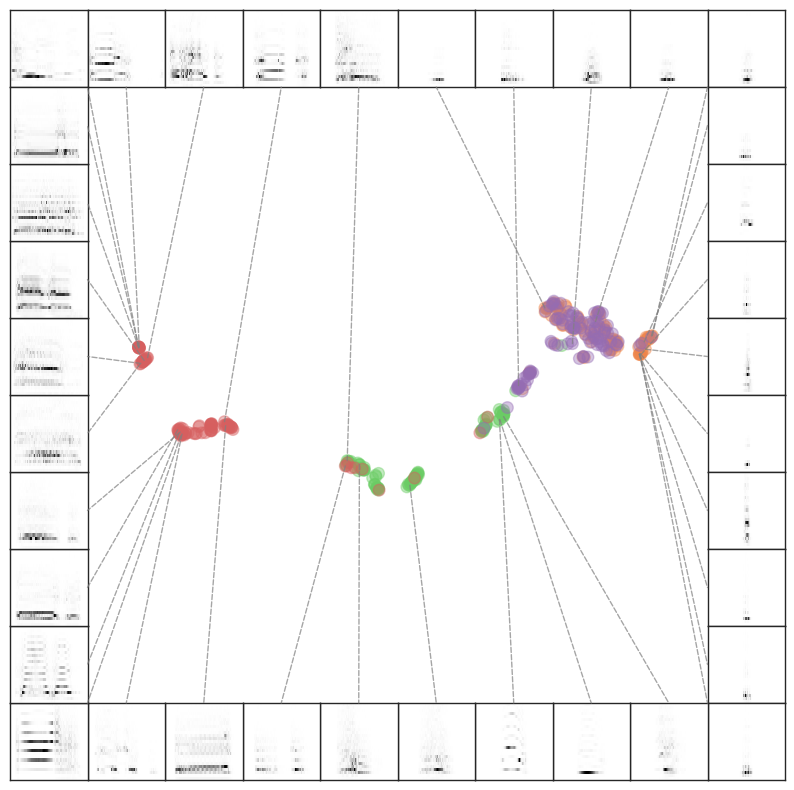

In [173]:
scatter_spec(
    vis_data_sub["embeddings"]["lfcc"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


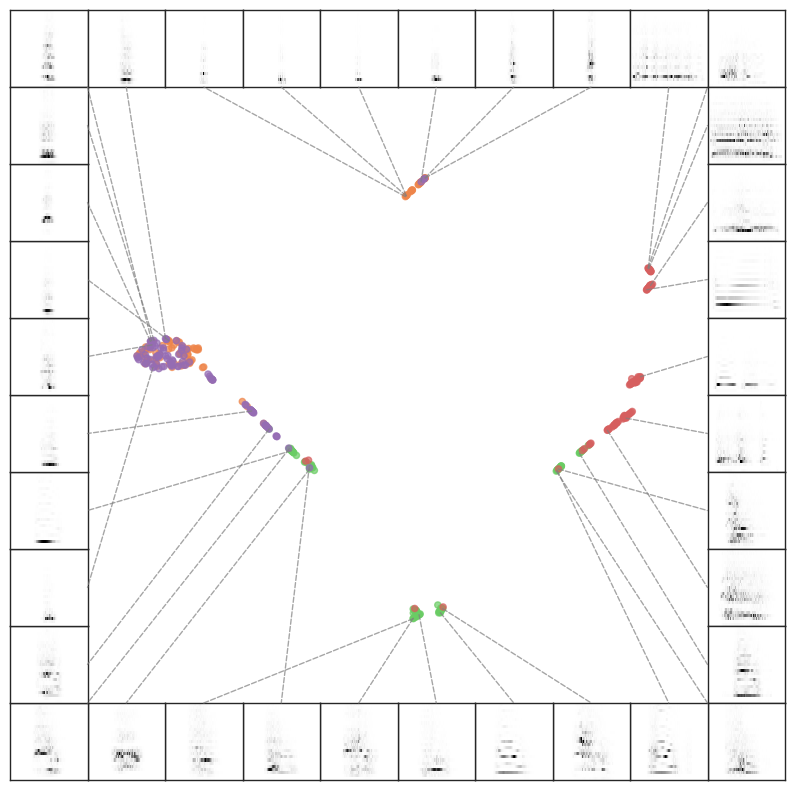

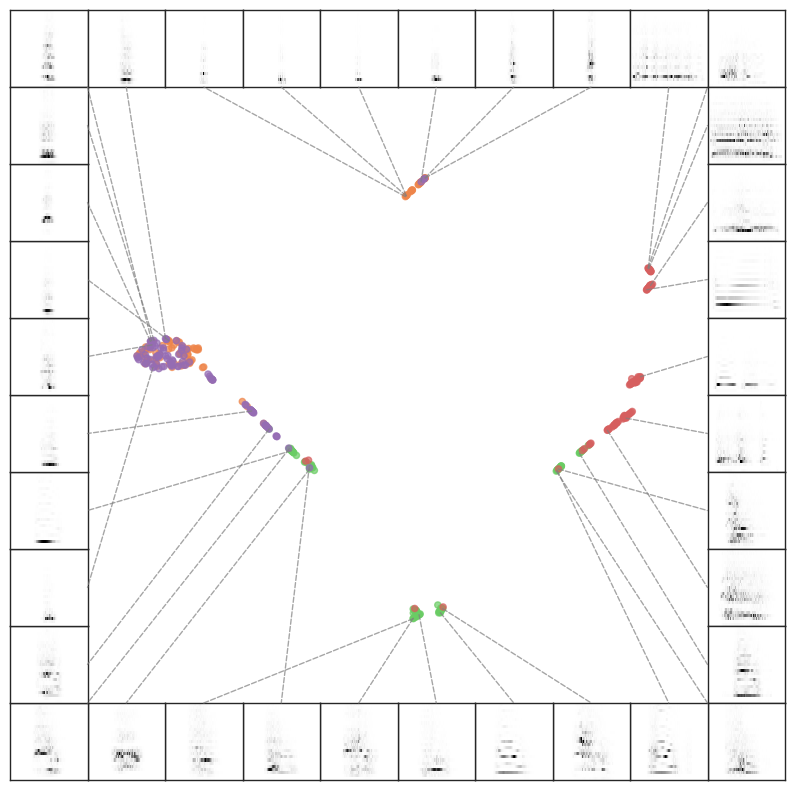

In [174]:
scatter_spec(
    vis_data_sub["embeddings"]["mfcc"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.7, "s": 20, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


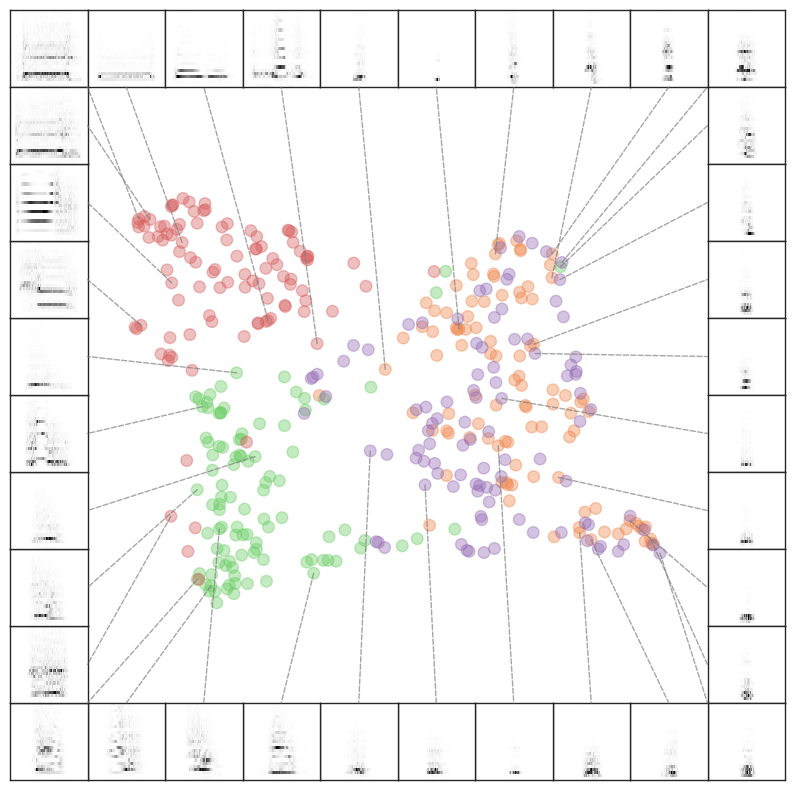

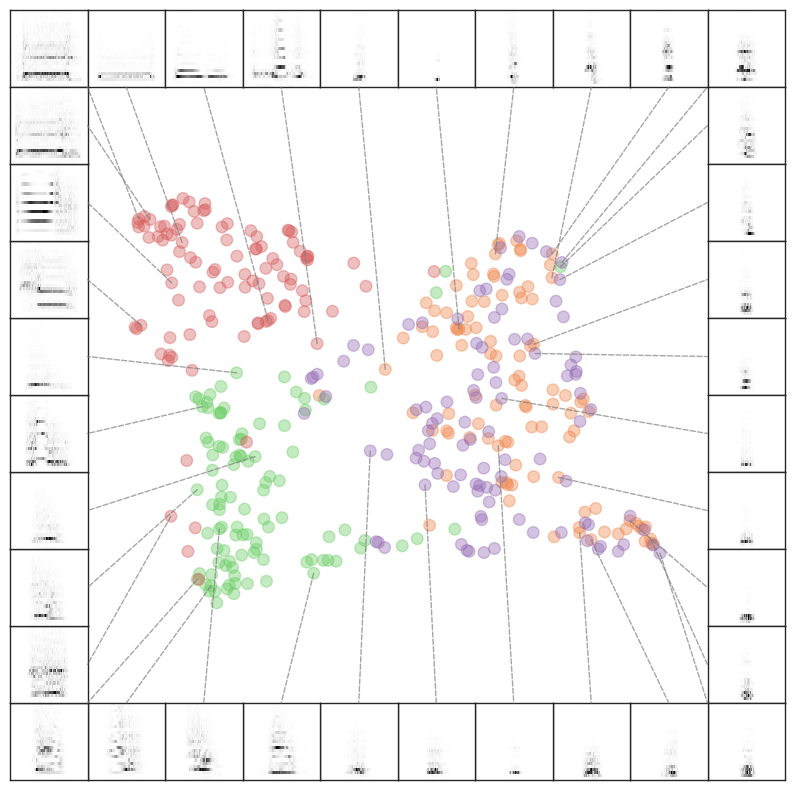

In [175]:
scatter_spec(
    vis_data_sub["embeddings"]["spec"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


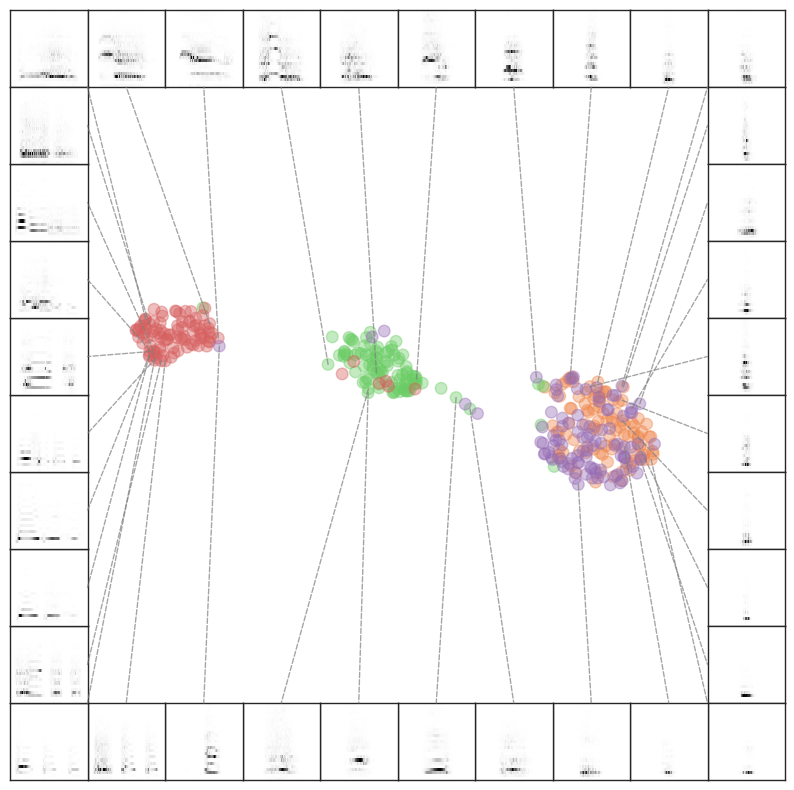

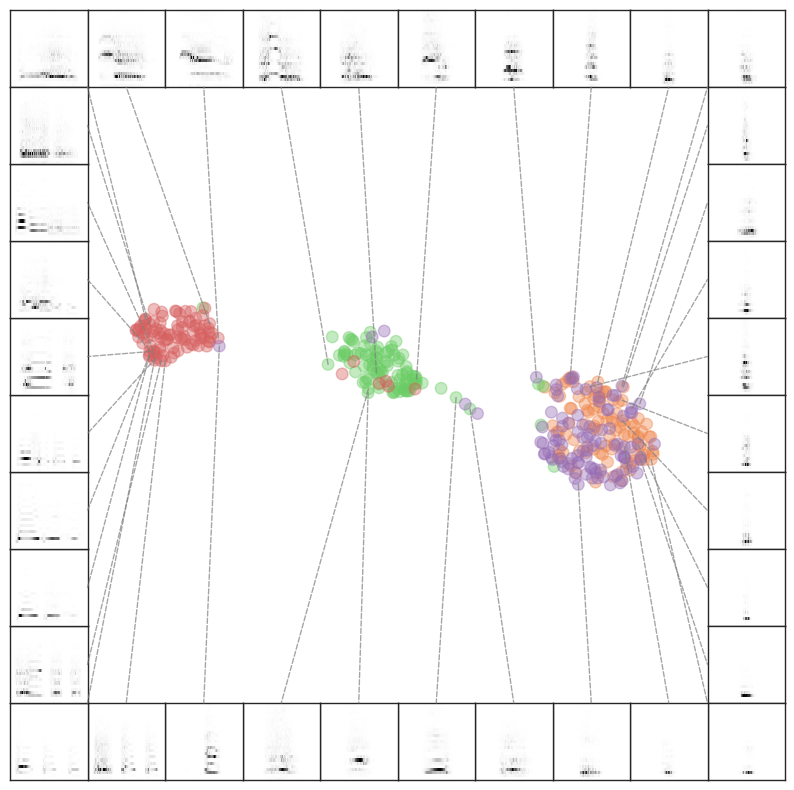

In [176]:
scatter_spec(
    vis_data_sub["embeddings"]["vae"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

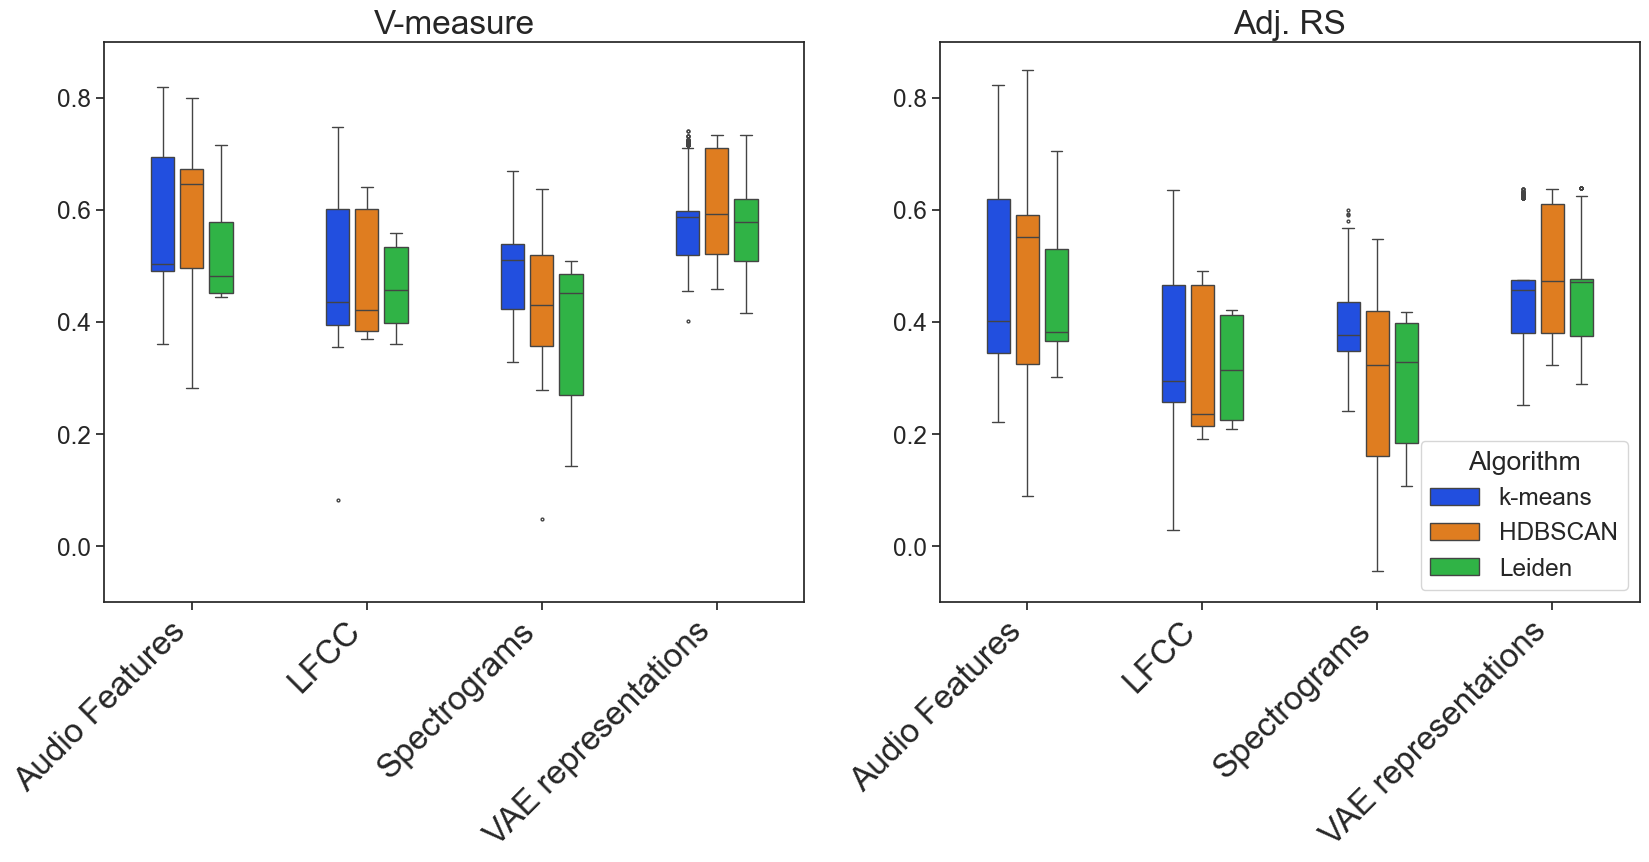

In [177]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.boxplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        gap=.2,
        fliersize=2,
        width=.5,
        palette="bright"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(-.1, .9)

plt.tight_layout()
plt.show()


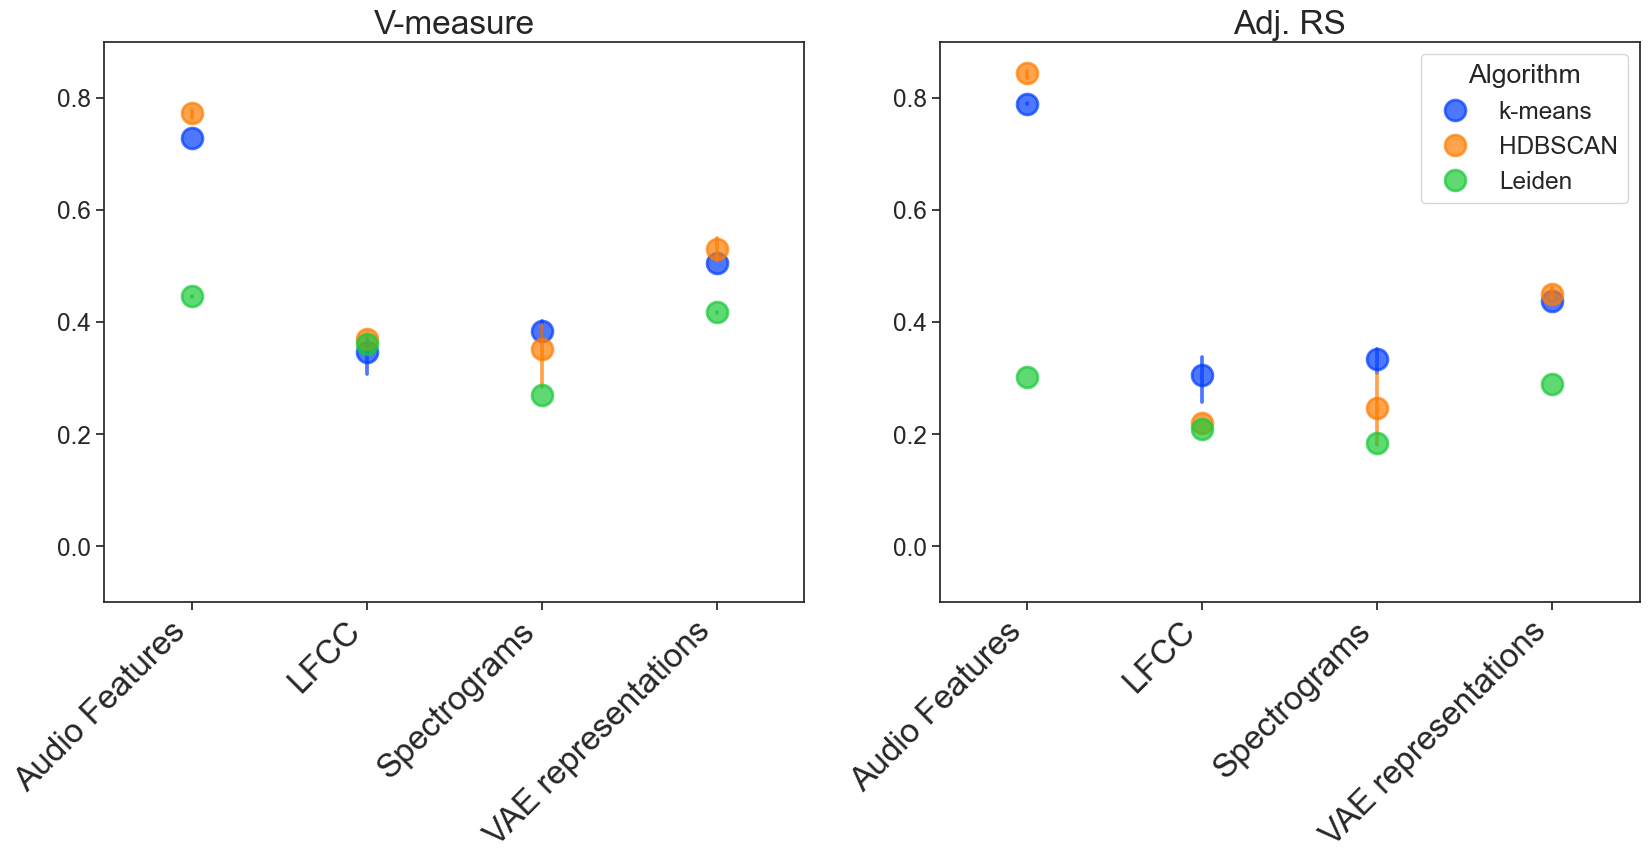

In [178]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")&(results_df['Subset size']=="complete dataset")], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        alpha=.7,
        palette="bright",
        linestyles="",
        markersize=15,
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(-.1, .9)

plt.tight_layout()
plt.show()


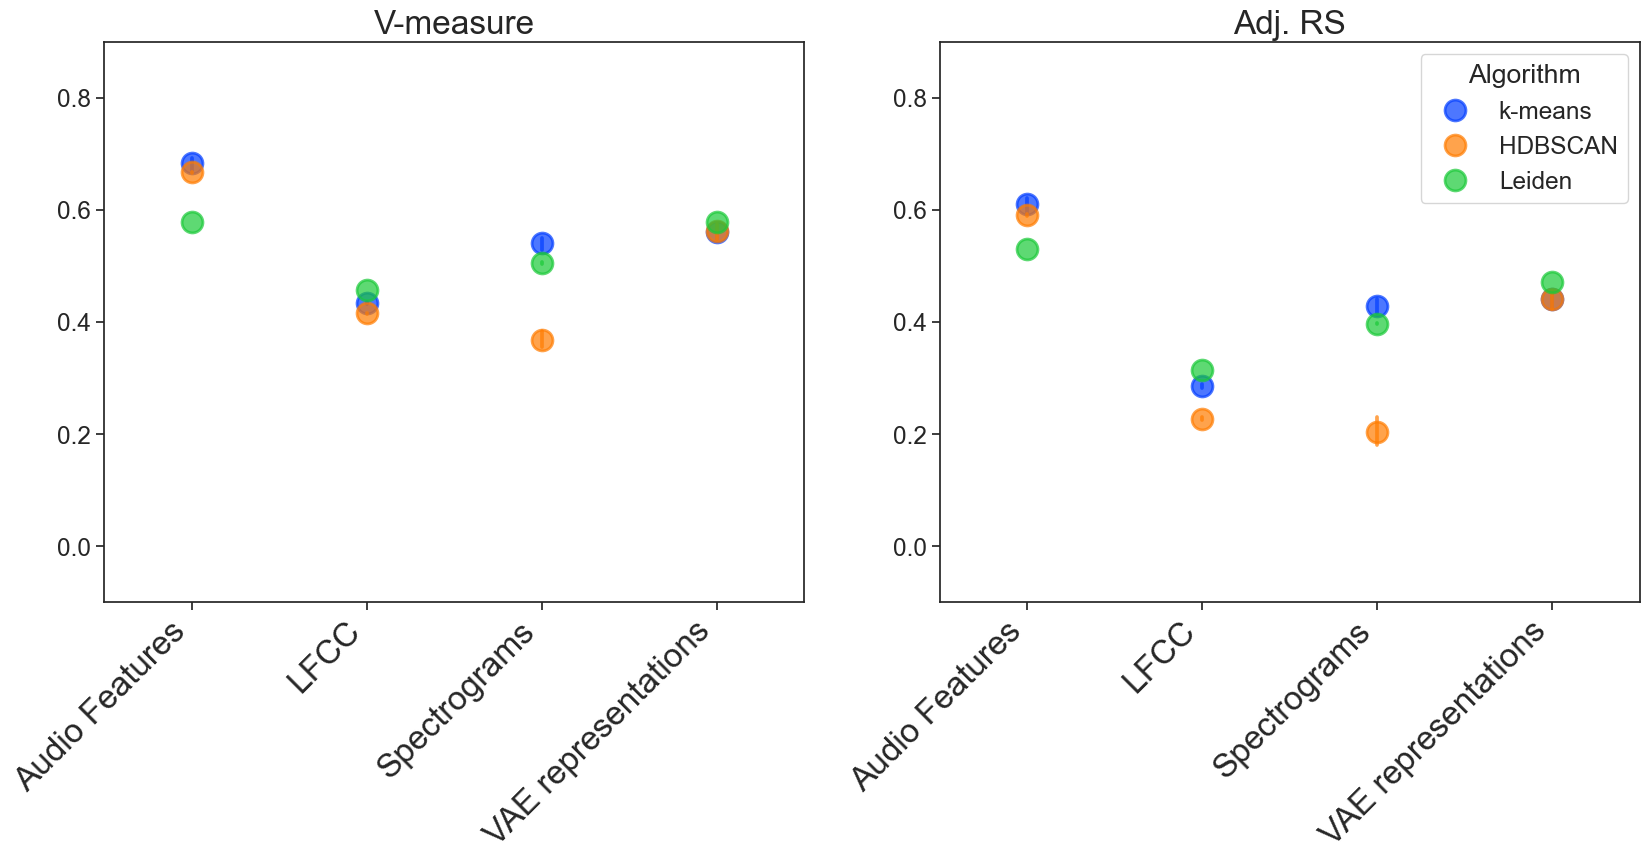

In [179]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")&(results_df['Subset size']==500)], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        alpha=.7,
        palette="bright",
        linestyles="",
        markersize=15,
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(-.1, .9)

plt.tight_layout()
plt.show()


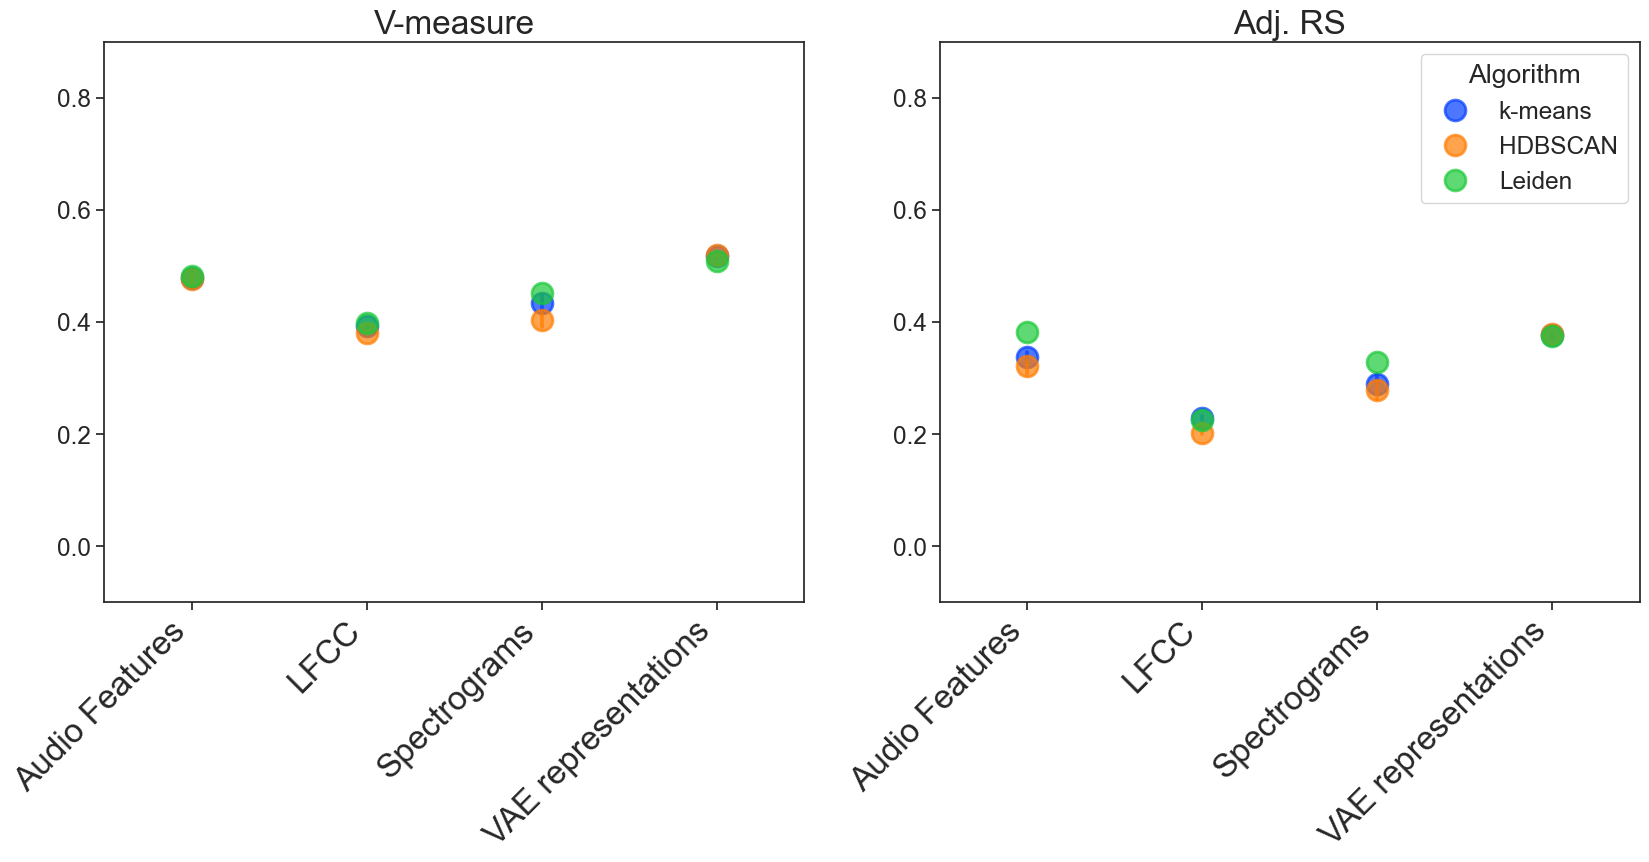

In [180]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")&(results_df['Subset size']==200)], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        alpha=.7,
        palette="bright",
        linestyles="",
        markersize=15,
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(-.1, .9)

plt.tight_layout()
plt.show()


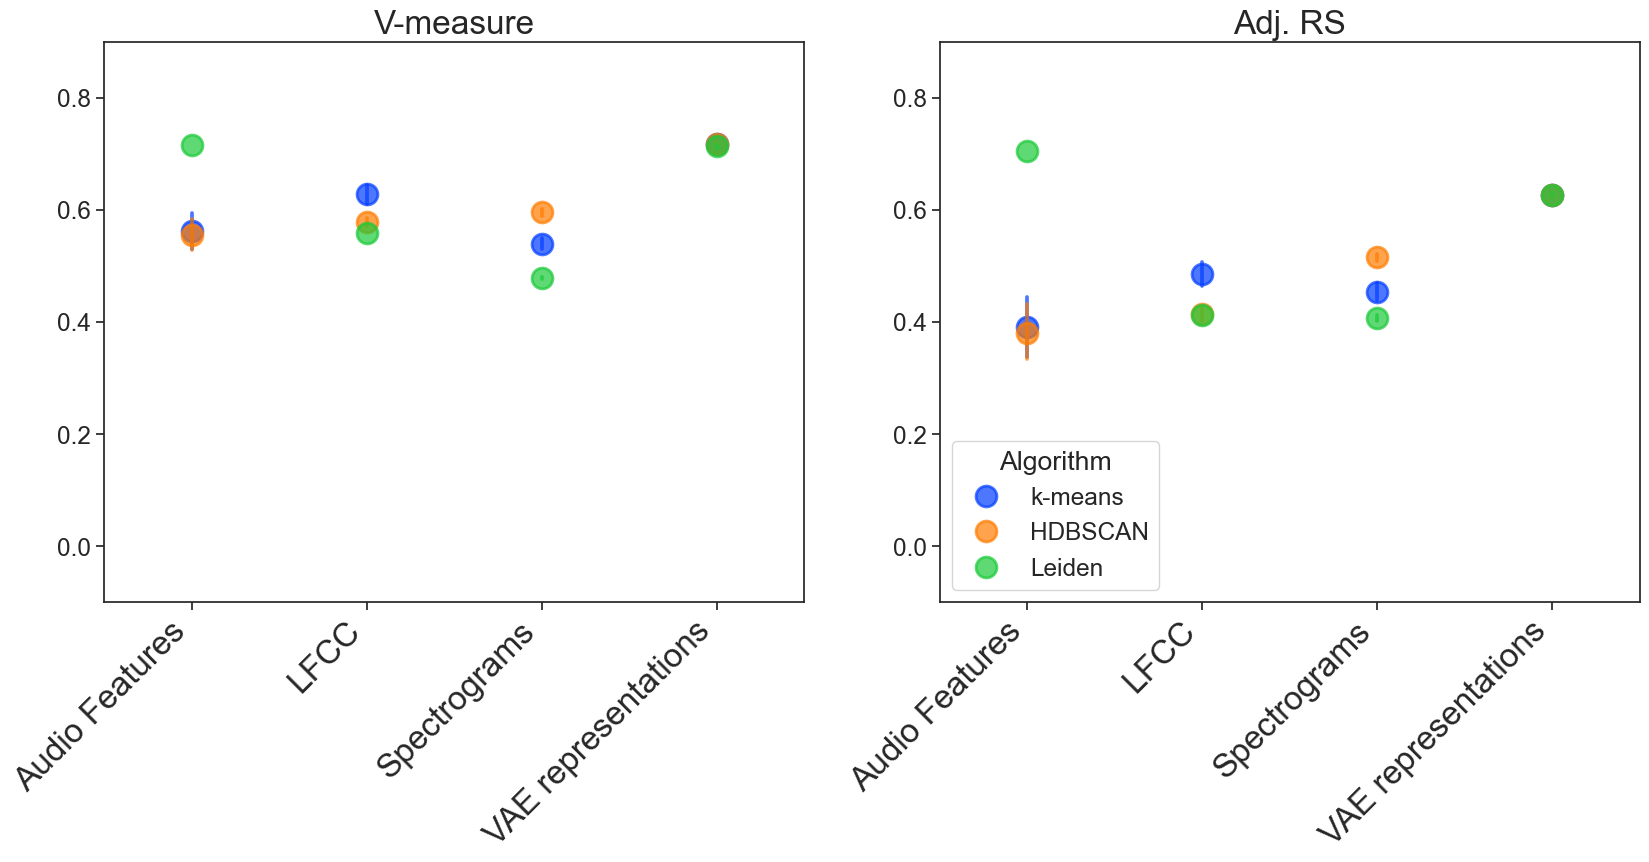

In [181]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")&(results_df['Subset size']==100)], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        alpha=.7,
        palette="bright",
        linestyles="",
        markersize=15,
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(-.1, .9)

plt.tight_layout()
plt.show()


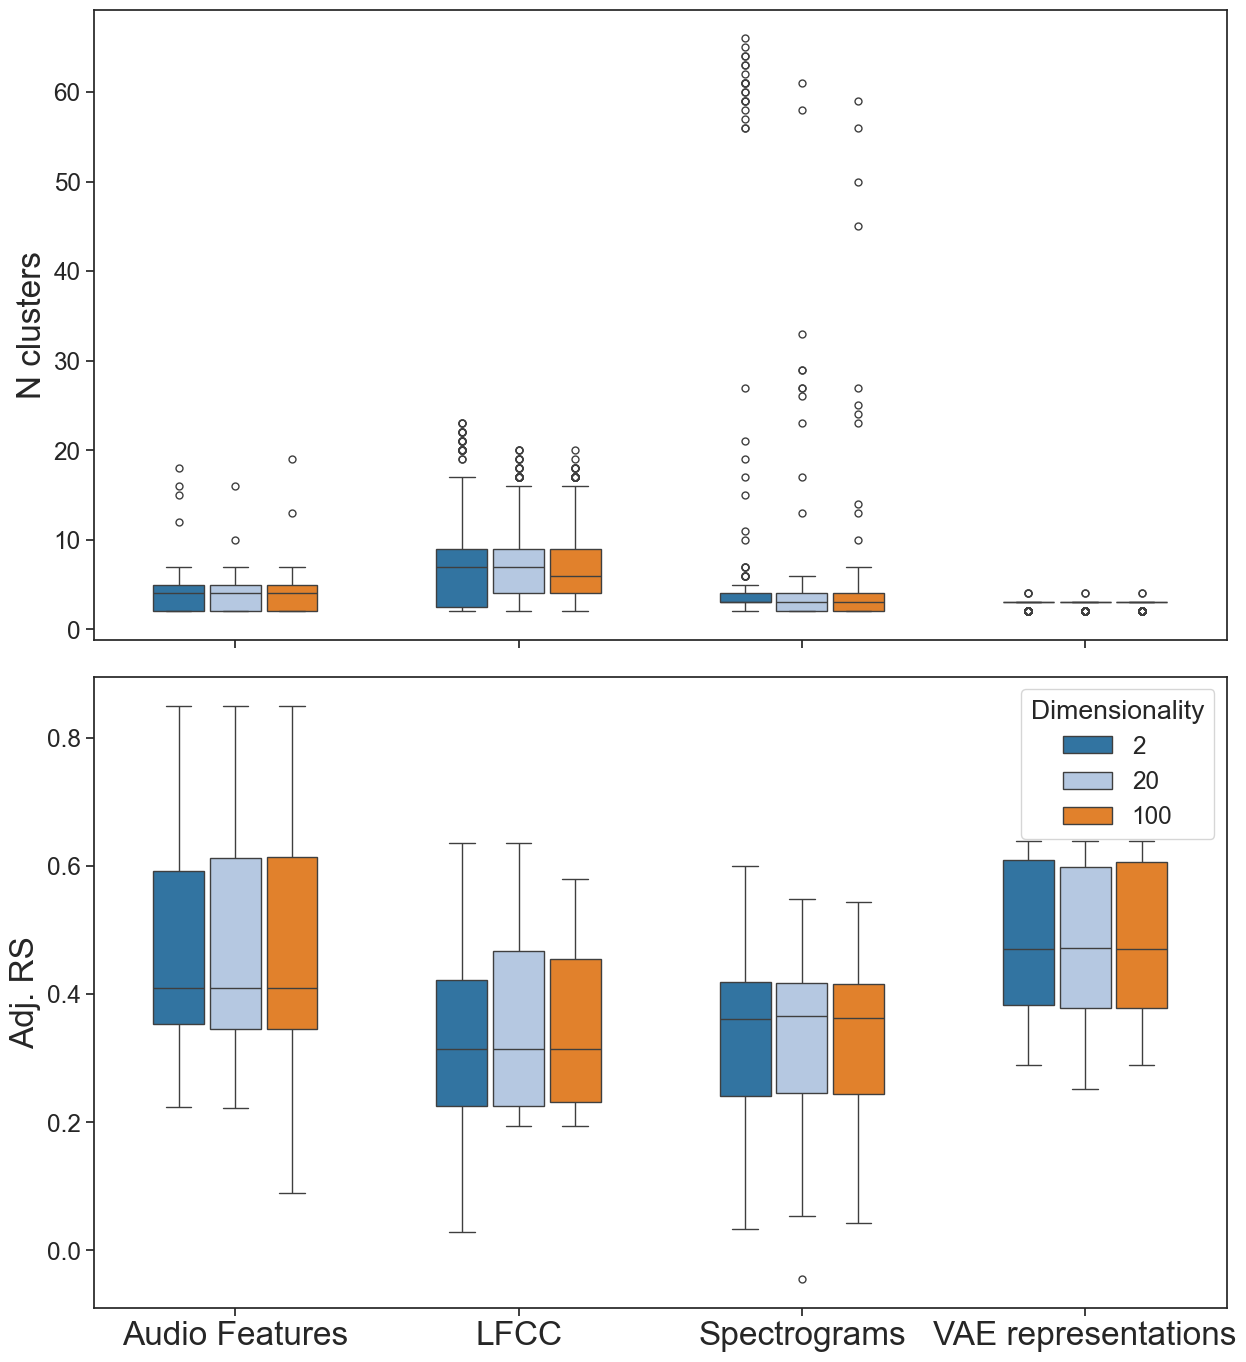

In [182]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(13, 14))

rows = ["N clusters", "Adj. RS"]
for i, row in enumerate(rows):
    sns.boxplot(
        x="Representation", 
        y=row, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Dimensionality", 
        legend=True if i == len(rows)-1 else False,
        gap=.1,
        fliersize=5,
        width=.6,
        palette="tab20"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    if i==1:
        axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], fontsize=24)#ha='right',rotation=45,
    else:
        axs[i].set_xticklabels("")
    # axs[i].set_title(row, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(row, fontsize=24)
    # axs[i].set_ylim(.0, .85)

plt.tight_layout()
plt.show()


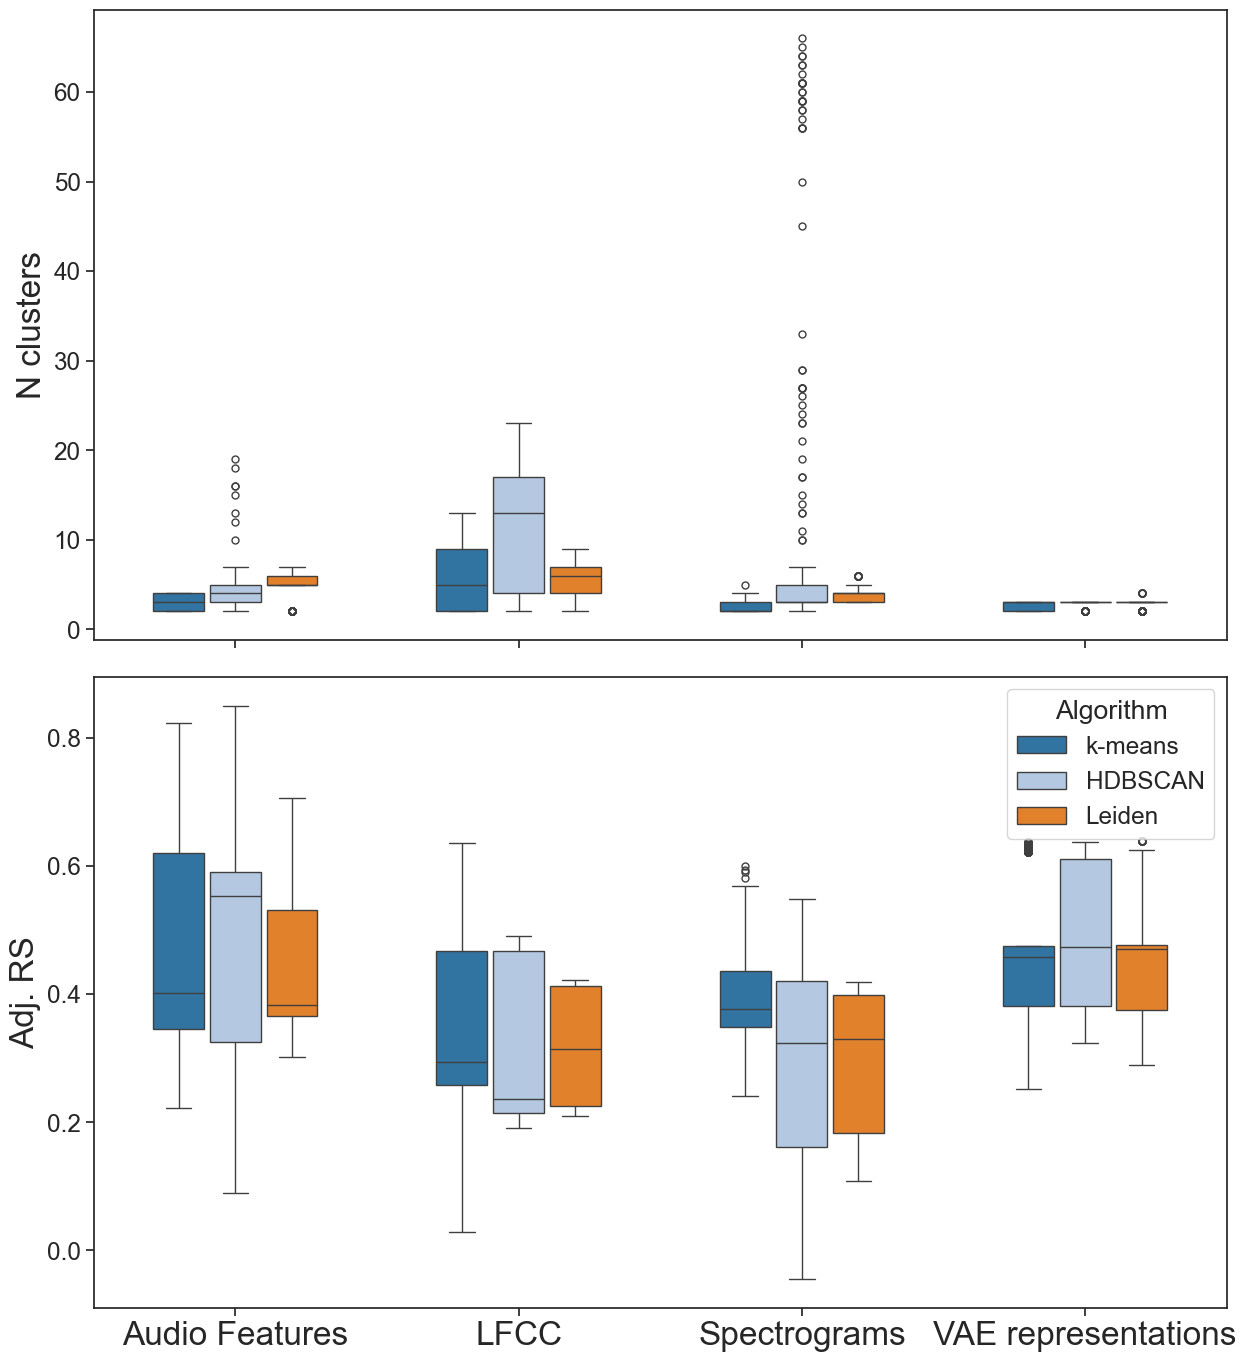

In [183]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(13, 14))

rows = ["N clusters", "Adj. RS"]
for i, row in enumerate(rows):
    sns.boxplot(
        x="Representation", 
        y=row, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(rows)-1 else False,
        gap=.1,
        fliersize=5,
        width=.6,
        palette="tab20"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    if i==1:
        axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], fontsize=24)#ha='right',rotation=45,
    else:
        axs[i].set_xticklabels("")
    # axs[i].set_title(row, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(row, fontsize=24)
    # axs[i].set_ylim(.0, .85)

plt.tight_layout()
plt.show()


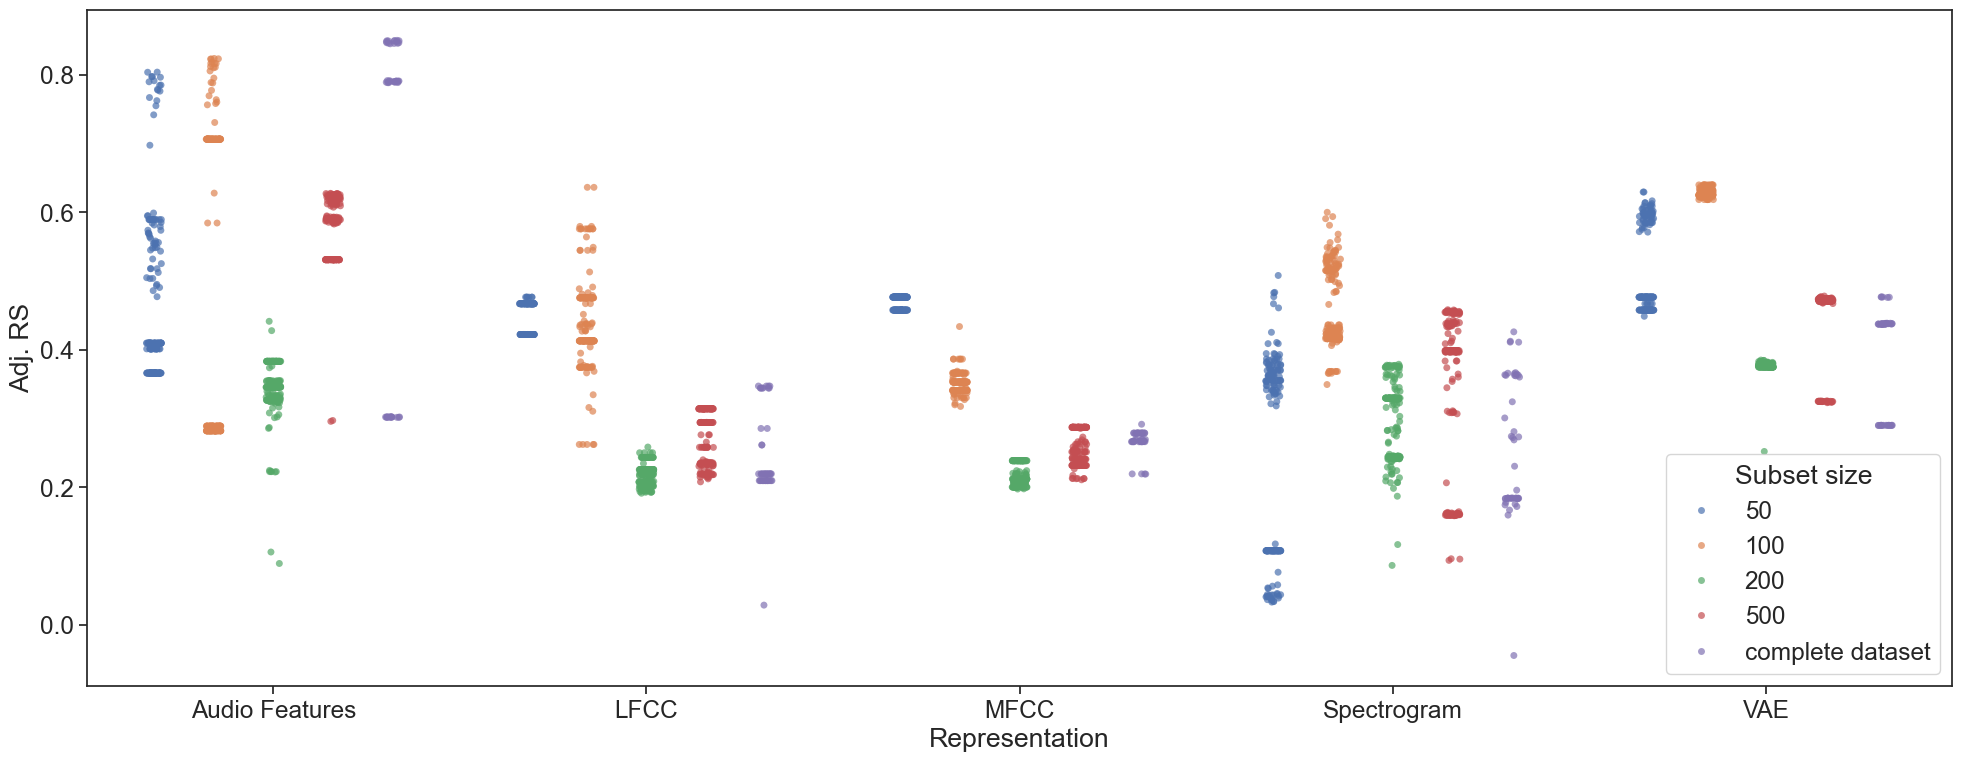

In [184]:
rows = ["Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["PAF", "LFCC", "Spectrogram", "VAE"]

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), sharex=True, sharey=True)

sns.stripplot(
    x="Representation", 
    y="Adj. RS",  
    data=results_df, 
    ax=axs, 
    hue="Subset size",
    alpha=.7,
    dodge=.3,
    legend=True
)
plt.tight_layout()
plt.show()

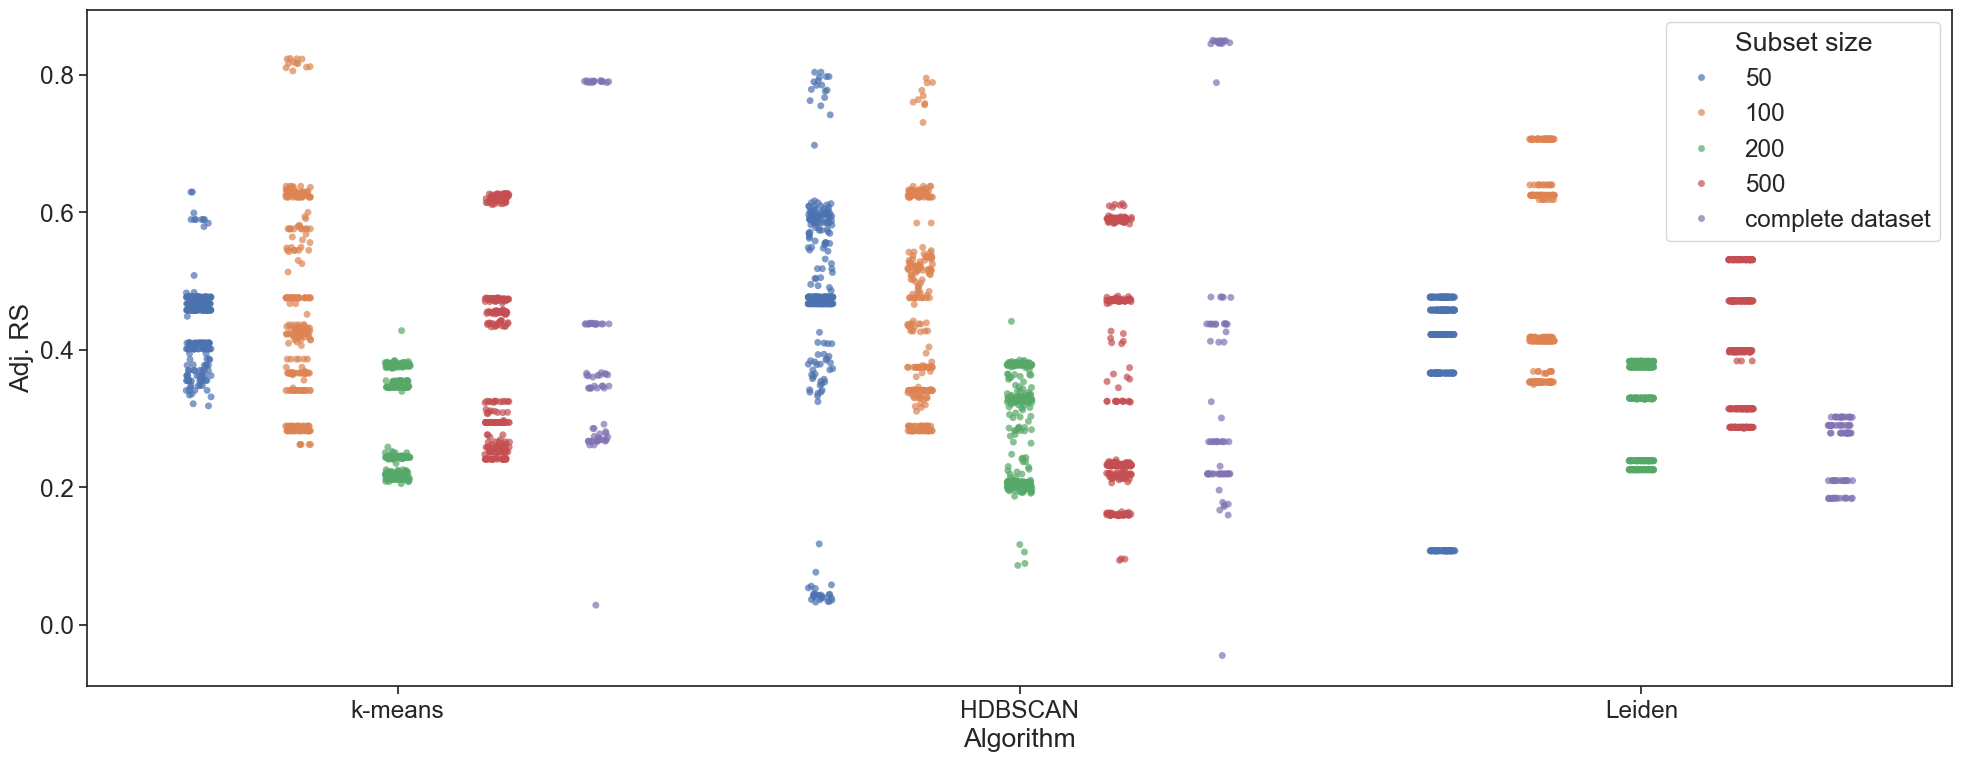

In [185]:
rows = ["Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["PAF", "LFCC", "Spectrogram", "VAE"]

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), sharex=True, sharey=True)

sns.stripplot(
    x="Algorithm", 
    y="Adj. RS",  
    data=results_df, 
    ax=axs, 
    hue="Subset size",
    alpha=.7,
    dodge=.3,
    legend=True
)
plt.tight_layout()
plt.show()

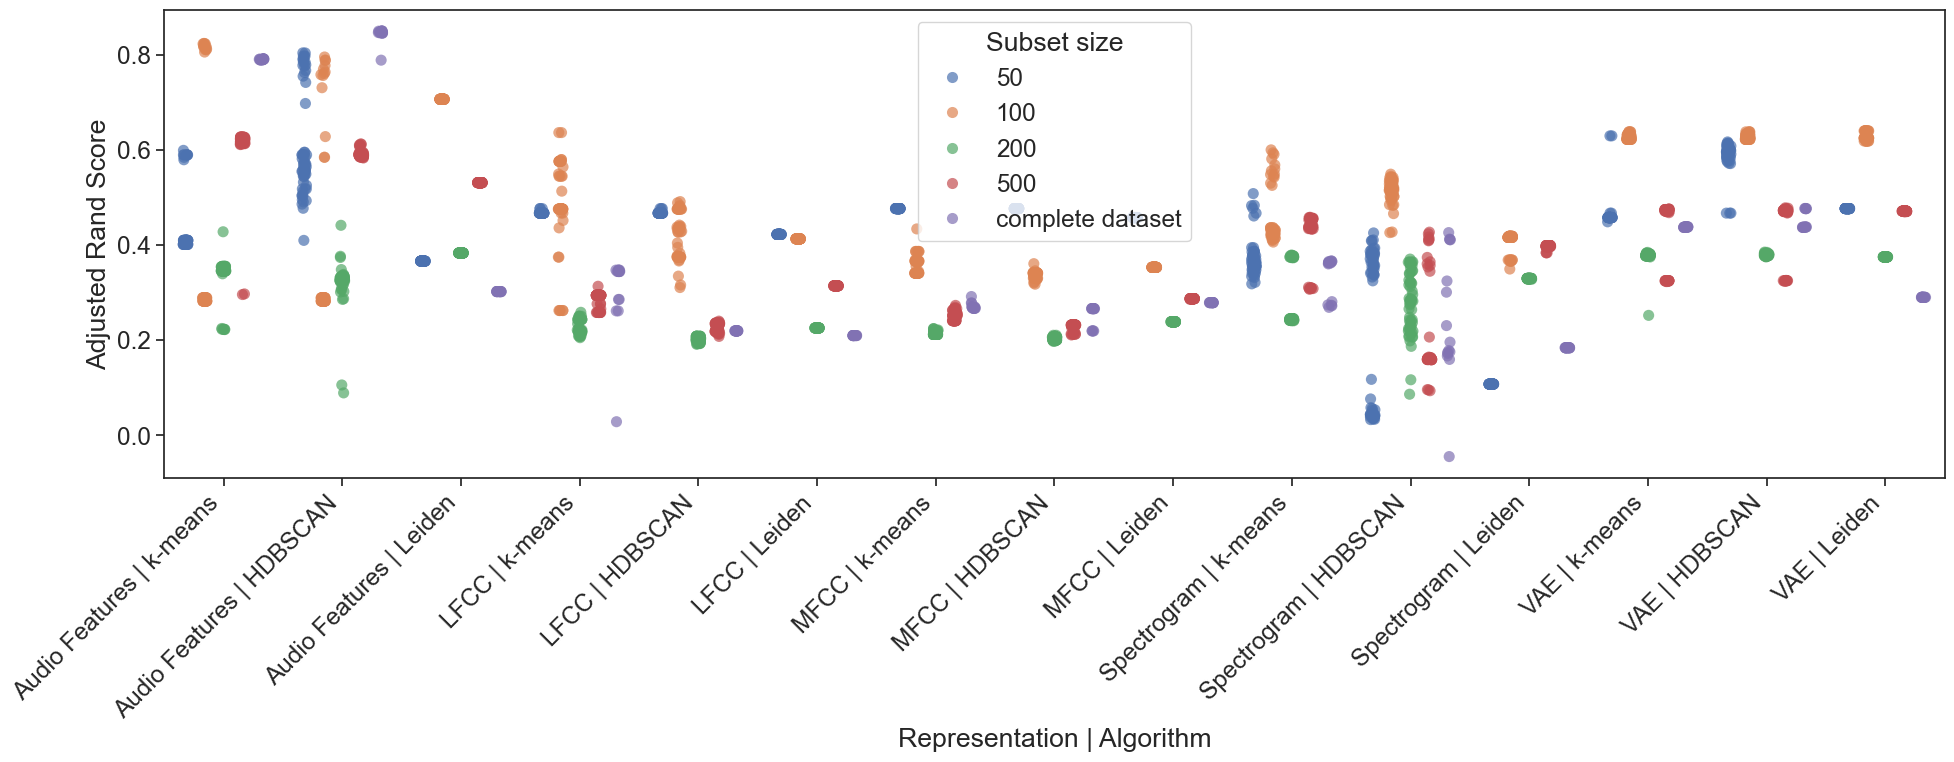

In [186]:
rows: list[str] = ["Adj. RS"]
columns: list[str] = ["k-means", "HDBSCAN", "Leiden"]
representations: list[str] = ["PAF", "LFCC", "Spectrogram", "VAE"]
sub_df = results_df.copy()
sub_df["Rep_Algo"] = sub_df["Representation"] + " | " + sub_df["Algorithm"]


fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), sharex=True, sharey=True)

sns.stripplot(
    x="Rep_Algo", 
    y="Adj. RS",  
    data=sub_df, 
    ax=axs, 
    hue="Subset size",
    alpha=.7,
    dodge=0.0001,
    legend=True,
    size=8,
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Representation | Algorithm")
plt.ylabel("Adjusted Rand Score")

plt.tight_layout()
plt.show()

# Raw numbers

In [187]:
sub_df = results_df[(results_df['Dimensionality']==20)]

In [188]:
for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].min())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].max())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].mean())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].std())

Audio Features
2
16
3.9215686274509802
1.79064868876364
LFCC
2
20
7.529411764705882
4.939607483754335
Spectrogram
2
61
4.294117647058823
6.536674603190405
VAE
2
4
2.772549019607843
0.4383570037596047


In [189]:
for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].min())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].max())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].mean())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].std())
    
    for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
        print("  "+rep)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].max())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].min())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].mean())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].std())

k-means
2
16
4.3623529411764705
3.191305126883762
  Audio Features
4
2
2.823529411764706
0.847636357737198
  LFCC
13
2
6.317647058823529
3.437232291587307
  Spectrogram
3
2
2.3176470588235296
0.46832438660872344
  VAE
3
2
2.6470588235294117
0.4807207473937337
HDBSCAN
2
61
7.209411764705882
7.425155222464473
  Audio Features
16
2
3.9411764705882355
1.8018042622437591
  LFCC
20
2
10.388235294117647
6.561239207952839
  Spectrogram
61
2
6.752941176470588
10.858292729909403
  VAE
3
2
2.8823529411764706
0.3241018617760822
Leiden
2
10
5.00235294117647
2.6639618172597705
  Audio Features
7
2
5.0
1.8257418583505538
  LFCC
9
2
5.882352941176471
2.5326993162099867
  Spectrogram
6
3
3.8117647058823527
0.8795848269422997
  VAE
4
2
2.788235294117647
0.4653241995042357


In [190]:
sub_df = results_df

for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].min())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].max())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].mean())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].std())
    
    for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
        print("  "+rep)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].max())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].min())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].mean())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].std())

k-means
2
16
4.3701960784313725
3.180995797377913
  Audio Features
4
2
2.8588235294117648
0.8250928057054334
  LFCC
13
2
6.184313725490196
3.369815793758761
  Spectrogram
5
2
2.388235294117647
0.5490317385457086
  VAE
3
2
2.6588235294117646
0.47503686992763394
HDBSCAN
2
66
8.065098039215686
9.803388901711422
  Audio Features
19
2
4.050980392156863
2.288569039300653
  LFCC
23
2
10.68235294117647
6.988536898749145
  Spectrogram
66
2
10.549019607843137
17.44836445812024
  VAE
3
2
2.8980392156862744
0.3031918106523105
Leiden
2
10
5.004705882352941
2.661719408159962
  Audio Features
7
2
5.0
1.8185396927681365
  LFCC
9
2
5.882352941176471
2.522708352940787
  Spectrogram
6
3
3.819607843137255
0.8911241259287388
  VAE
4
2
2.792156862745098
0.4694791624328206


In [191]:
for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["V-measure"].mean())
    print(sub_df[sub_df["Representation"]==rep]["V-measure"].std())
    for algo in ["k-means", "HDBSCAN", "Leiden"]:
        print("  "+algo)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["V-measure"].mean())
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["V-measure"].std())

Audio Features
0.5770743854926264
0.1122286837180392
  k-means
   0.5733062870890407
   0.11335620094038584
  HDBSCAN
   0.6071184328654957
   0.11252012190384293
  Leiden
   0.5507984365233427
   0.10373526383490032
LFCC
0.4905361822897455
0.09635262361509205
  k-means
   0.5048013284750763
   0.11325084506625949
  HDBSCAN
   0.4873011751547926
   0.10040302947645023
  Leiden
   0.4795060432393676
   0.0684186964033554
Spectrogram
0.4396716146888133
0.11753850828808322
  k-means
   0.48463445862641313
   0.07089441361025085
  HDBSCAN
   0.4470617903502813
   0.10217970045466178
  Leiden
   0.3873185950897455
   0.14578031392330806
VAE
0.6017080495324975
0.08651296987359819
  k-means
   0.5922784010173054
   0.08145526843414679
  HDBSCAN
   0.6186133668942638
   0.09088225993772948
  Leiden
   0.5942323806859229
   0.08476780086648933


In [192]:
for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["Adj. RS"].mean())
    print(sub_df[sub_df["Representation"]==rep]["Adj. RS"].std())
    for algo in ["k-means", "HDBSCAN", "Leiden"]:
        print("  "+algo)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["Adj. RS"].mean())
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["Adj. RS"].std())

Audio Features
0.482009097539503
0.16739463132255367
  k-means
   0.4634192102809291
   0.1717353802147576
  HDBSCAN
   0.49750543485648263
   0.18535508362694464
  Leiden
   0.48510264748109727
   0.1408415540629125
LFCC
0.3401934563057817
0.10941894576439459
  k-means
   0.36358983577232384
   0.11940633376850515
  HDBSCAN
   0.32127118325972154
   0.11718959247075998
  Leiden
   0.3357193498852997
   0.08421051884454357
Spectrogram
0.32989201190391937
0.12985255302597942
  k-means
   0.38333621349676505
   0.08161276025618222
  HDBSCAN
   0.3033560210952433
   0.15795536781903405
  Leiden
   0.3029838011197499
   0.12167959367304994
VAE
0.4852556940665661
0.10146545101473267
  k-means
   0.47475725507080635
   0.0964203808172171
  HDBSCAN
   0.5053409110572015
   0.10583930635936263
  Leiden
   0.47566891607169065
   0.09929756299405226


In [193]:
for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].min())
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].max())
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].mean())
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].std())
    
    for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
        print("  "+rep)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].max())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].min())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].mean())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].std())

k-means
0.028466224755781953
0.8236372690655634
0.4013909780772404
0.13192672537724734
  Audio Features
0.8236372690655634
0.22209495171885224
0.4634192102809291
0.1717353802147576
  LFCC
0.6361696896499666
0.028466224755781953
0.36358983577232384
0.11940633376850515
  Spectrogram
0.5998612500550293
0.24057395782414376
0.38333621349676505
0.08161276025618222
  VAE
0.6377281847260811
0.2519828784384728
0.47475725507080635
0.0964203808172171
HDBSCAN
-0.04480083047849346
0.8499394886191471
0.3871749249313606
0.16666559506101855
  Audio Features
0.8499394886191471
0.08903371749334772
0.49750543485648263
0.18535508362694464
  LFCC
0.4911227654738884
0.19122785432041609
0.32127118325972154
0.11718959247075998
  Spectrogram
0.5487881976248605
-0.04480083047849346
0.3033560210952433
0.15795536781903405
  VAE
0.6377281847260811
0.32368039238477114
0.5053409110572015
0.10583930635936263
Leiden
0.10750880311499865
0.7062292908153519
0.38605478941020155
0.13289207375308787
  Audio Features
0.70622

In [194]:
!pip install statsmodels

In [195]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

results_without_preset = results_df.copy()[~(results_df["Algorithm"].isin(["k-means-preset", "Leiden-preset"]))]

results_without_preset.rename(columns={'Subset size': 'Subset_size', 'V-measure': 'V_measure', 'Adj. RS': 'Adj_RS', 'Distance metric': 'distance_metric'}, inplace=True)

formula = "V_measure ~ C(Representation) + C(Algorithm) + Subset_size + Dimensionality"
glm_beta = smf.glm(formula, data=results_without_preset,
                    family=sm.families.Binomial(link=sm.families.links.logit())).fit()
# glm_beta = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.logit())).fit()
print(glm_beta.summary())

formula = "Adj_RS ~ C(Representation) + C(Algorithm) + Subset_size + Dimensionality"
glm_beta = smf.glm(formula, data=results_without_preset,
                    family=sm.families.Binomial(link=sm.families.links.logit())).fit()
# glm_beta = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.logit())).fit()
print(glm_beta.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              V_measure   No. Observations:                 3825
Model:                            GLM   Df Residuals:                     3813
Model Family:                Binomial   Df Model:                           11
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1719.3
Date:                Thu, 02 Oct 2025   Deviance:                       108.06
Time:                        17:07:58   Pearson chi2:                     105.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02919
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(
